In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

master_file = (
    project_root
    / "data"
    / "processed"
    / "retailiq_cleaned_master.csv.gz"
)

clean_df = pd.read_csv(
    master_file,
    compression="gzip",
    parse_dates=["InvoiceDate"],
    low_memory=False
)

clean_df["CustomerID"] = pd.to_numeric(
    clean_df["CustomerID"],
    errors="coerce"
).astype("Int64")

print("Dataset shape:", clean_df.shape)
print(
    "Date range:",
    clean_df["InvoiceDate"].min(),
    "to",
    clean_df["InvoiceDate"].max()
)

Dataset shape: (1033036, 29)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [5]:
current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

segmentation_figure_dir = (
    project_root
    / "reports"
    / "figures"
    / "customer_segmentation"
)

segmentation_figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Figures will be saved to:")
print(segmentation_figure_dir)

Figures will be saved to:
c:\Github\retail-financial-intelligence\reports\figures\customer_segmentation


In [6]:
if not pd.api.types.is_bool_dtype(
    clean_df["IsExactReversalPair"]
):
    clean_df["IsExactReversalPair"] = (
        clean_df["IsExactReversalPair"]
        .astype("string")
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False
        })
        .fillna(False)
        .astype(bool)
    )

For recency and frequency, exclude sales that were exactly reversed:

In [7]:
customer_behavior_sales = clean_df.loc[
    clean_df["CustomerID"].notna()
    & clean_df["TransactionType"].eq("Sale")
    & ~clean_df["IsExactReversalPair"]
].copy()

In [8]:
customer_net_transactions = clean_df.loc[
    clean_df["CustomerID"].notna()
    & clean_df["TransactionType"].isin([
        "Sale",
        "Cancellation"
    ])
].copy()

In [9]:
segmentation_source_check = pd.Series({
    "Behaviour-sale rows": len(
        customer_behavior_sales
    ),
    "Net-transaction rows": len(
        customer_net_transactions
    ),
    "Behaviour customers": (
        customer_behavior_sales[
            "CustomerID"
        ].nunique()
    ),
    "Missing IDs in behaviour data": (
        customer_behavior_sales[
            "CustomerID"
        ].isna().sum()
    ),
    "Exact reversals in behaviour data": (
        customer_behavior_sales[
            "IsExactReversalPair"
        ].sum()
    )
})

segmentation_source_check

Behaviour-sale rows                  770577
Net-transaction rows                 794199
Behaviour customers                    5839
Missing IDs in behaviour data             0
Exact reversals in behaviour data         0
dtype: int64

Building customer-level segmentation features

In [10]:
reference_date = (
    clean_df["InvoiceDate"]
    .max()
    .normalize()
    + pd.Timedelta(days=1)
)

print("Segmentation reference date:", reference_date)

Segmentation reference date: 2011-12-10 00:00:00


Create behavioural customer features

In [11]:
customer_features = (
    customer_behavior_sales
    .groupby("CustomerID")
    .agg(
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("Invoice", "nunique"),
        GrossMonetary=("Revenue", "sum"),
        UnitsPurchased=("Quantity", "sum"),
        UniqueProducts=(
            "StockCodeNormalized",
            "nunique"
        )
    )
)

In [12]:
customer_features["Recency"] = (
    reference_date
    - customer_features[
        "LastPurchase"
    ].dt.normalize()
).dt.days

customer_features["CustomerTenureDays"] = (
    reference_date
    - customer_features[
        "FirstPurchase"
    ].dt.normalize()
).dt.days

customer_features["AverageOrderValue"] = (
    customer_features["GrossMonetary"]
    / customer_features["Frequency"]
)

customer_features["OrdersPer30Days"] = (
    customer_features["Frequency"]
    / customer_features[
        "CustomerTenureDays"
    ].clip(lower=1)
    * 30
)

Add cancellations and net monetary value

In [13]:
financial_source = (
    customer_net_transactions.copy()
)

financial_source["CancellationValue"] = (
    np.where(
        financial_source[
            "TransactionType"
        ].eq("Cancellation"),
        financial_source["Revenue"].abs(),
        0
    )
)

financial_source["CancellationInvoice"] = (
    financial_source["Invoice"].where(
        financial_source[
            "TransactionType"
        ].eq("Cancellation")
    )
)

In [14]:
customer_financial_features = (
    financial_source
    .groupby("CustomerID")
    .agg(
        NetMonetary=("Revenue", "sum"),
        CancellationValue=(
            "CancellationValue",
            "sum"
        ),
        CancellationInvoices=(
            "CancellationInvoice",
            "nunique"
        )
    )
)

In [15]:
customer_features = (
    customer_features
    .join(
        customer_financial_features,
        how="left"
    )
)

financial_columns = [
    "NetMonetary",
    "CancellationValue",
    "CancellationInvoices"
]

customer_features[financial_columns] = (
    customer_features[financial_columns]
    .fillna(0)
)

customer_features["CancellationRatePercent"] = (
    customer_features["CancellationInvoices"]
    / (
        customer_features["Frequency"]
        + customer_features[
            "CancellationInvoices"
        ]
    ).replace(0, np.nan)
    * 100
)

Validate the feature table

In [16]:
feature_validation = pd.Series({
    "Customers": len(customer_features),
    "Missing values": int(
        customer_features.isna().sum().sum()
    ),
    "Invalid frequency": int(
        customer_features["Frequency"].le(0).sum()
    ),
    "Negative recency": int(
        customer_features["Recency"].lt(0).sum()
    ),
    "Negative tenure": int(
        customer_features[
            "CustomerTenureDays"
        ].lt(0).sum()
    ),
    "Negative net monetary customers": int(
        customer_features[
            "NetMonetary"
        ].lt(0).sum()
    )
})

feature_validation

Customers                          5839
Missing values                        0
Invalid frequency                     0
Negative recency                      0
Negative tenure                       0
Negative net monetary customers       3
dtype: int64

In [17]:
customer_features[
    [
        "Recency",
        "Frequency",
        "GrossMonetary",
        "NetMonetary",
        "AverageOrderValue",
        "UnitsPurchased",
        "UniqueProducts",
        "CancellationRatePercent"
    ]
].describe(
    percentiles=[
        0.01,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T.round(2)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
Recency,5839.0,200.90,208.61,1.00,2.00,26.00,96.00,380.00,624.00,727.00,739.00
Frequency,5839.0,6.22,12.64,1.00,1.00,1.00,3.00,7.00,20.00,45.62,369.00
GrossMonetary,5839.0,2829.57,13900.45,2.90,43.45,336.24,851.01,2206.94,8990.29,26811.07,579128.64
NetMonetary,5839.0,2800.49,13835.45,-1343.24,40.65,332.52,842.41,2173.57,8917.53,26525.10,578408.64
AverageOrderValue,5839.0,363.66,533.53,2.90,36.38,174.96,275.50,409.27,860.44,1852.38,19809.75
UnitsPurchased,5839.0,1731.24,8592.07,1.00,12.00,188.00,480.00,1344.00,5259.60,16064.48,365114.00
UniqueProducts,5839.0,81.88,116.08,1.00,1.00,19.00,45.00,103.00,281.00,502.62,2507.00
CancellationRatePercent,5839.0,11.17,16.19,0.00,0.00,0.00,0.00,20.00,50.00,56.15,80.00


Prepare the modelling table

In [18]:
segmentation_df = customer_features.copy()

segmentation_df["Monetary"] = (
    segmentation_df["NetMonetary"]
)

clustering_features = [
    "Recency",
    "Frequency",
    "Monetary"
]

X_raw = (
    segmentation_df[
        clustering_features
    ]
    .astype("float64")
    .copy()
)

In [19]:
assert X_raw.notna().all().all()
assert np.isfinite(X_raw.to_numpy()).all()
assert X_raw.nunique().gt(1).all()

print("Clustering data shape:", X_raw.shape)

Clustering data shape: (5839, 3)


In [20]:
feature_diagnostics = pd.DataFrame({
    "Minimum": X_raw.min(),
    "Median": X_raw.median(),
    "Mean": X_raw.mean(),
    "Maximum": X_raw.max(),
    "Skewness": X_raw.skew()
})

feature_diagnostics.round(2)

,Minimum,Median,Mean,Maximum,Skewness
Recency,1.00,96.00,200.90,739.00,0.89
Frequency,1.00,3.00,6.22,369.00,11.96
Monetary,-1343.24,842.41,2800.49,578408.64,26.82


Count IQR outliers for documentation:

In [21]:
outlier_summary = []

for feature in clustering_features:
    q1 = X_raw[feature].quantile(0.25)
    q3 = X_raw[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (X_raw[feature] < lower_bound)
        | (X_raw[feature] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": feature,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCustomers": int(outlier_count),
        "OutlierPercent": (
            outlier_count / len(X_raw) * 100
        )
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

outlier_summary.round(2)

,Feature,LowerBound,UpperBound,OutlierCustomers,OutlierPercent
0,Recency,-505.00,911.00,0,0.00
1,Frequency,-8.00,16.00,421,7.21
2,Monetary,-2429.05,4935.15,618,10.58


Create the preprocessing pipeline

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    PowerTransformer,
    StandardScaler
)

preprocessing_pipeline = Pipeline(
    steps=[
        (
            "power_transform",
            PowerTransformer(
                method="yeo-johnson",
                standardize=False
            )
        ),
        (
            "standard_scaler",
            StandardScaler()
        )
    ]
)

Fit and transform for cluster evaluation:

In [23]:
X_processed = (
    preprocessing_pipeline
    .fit_transform(X_raw)
)

X_processed = pd.DataFrame(
    X_processed,
    index=X_raw.index,
    columns=clustering_features
)

X_processed.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.292989,-0.472534,-0.438040
12347,-1.741266,0.971136,0.548809
12348,-0.215685,0.535605,-0.016113
12349,-1.007741,-0.007558,0.352476
12350,0.826258,-1.264832,-0.384779


In [24]:
transformation_validation = pd.DataFrame({
    "Mean": X_processed.mean(),
    "StandardDeviation": X_processed.std(
        ddof=0
    ),
    "Skewness": X_processed.skew(),
    "Minimum": X_processed.min(),
    "Maximum": X_processed.max()
})

transformation_validation.round(3)

,Mean,StandardDeviation,Skewness,Minimum,Maximum
Recency,0.0,1.0,-0.108,-2.000,1.607
Frequency,0.0,1.0,0.166,-1.265,2.501
Monetary,-0.0,1.0,1.373,-34.146,24.537


In [25]:
assert np.isfinite(
    X_processed.to_numpy()
).all()

assert np.allclose(
    X_processed.mean(),
    0,
    atol=1e-6
)

assert np.allclose(
    X_processed.std(ddof=0),
    1,
    atol=1e-6
)

print("Preprocessing validation passed.")

Preprocessing validation passed.


In [26]:
def create_rfm_score(
    series,
    higher_is_better=True
):
    percentile_rank = series.rank(
        method="average",
        pct=True
    )

    score = (
        np.ceil(percentile_rank * 5)
        .clip(1, 5)
        .astype("int8")
    )

    if not higher_is_better:
        score = 6 - score

    return score

In [27]:
# Lower Recency is better
segmentation_df["RScore"] = create_rfm_score(
    segmentation_df["Recency"],
    higher_is_better=False
)

# Higher Frequency is better
segmentation_df["FScore"] = create_rfm_score(
    segmentation_df["Frequency"],
    higher_is_better=True
)

# Higher Monetary value is better
segmentation_df["MScore"] = create_rfm_score(
    segmentation_df["Monetary"],
    higher_is_better=True
)

In [28]:
segmentation_df["RFMCode"] = (
    segmentation_df["RScore"].astype(str)
    + segmentation_df["FScore"].astype(str)
    + segmentation_df["MScore"].astype(str)
)

segmentation_df["RFMTotal"] = (
    segmentation_df["RScore"]
    + segmentation_df["FScore"]
    + segmentation_df["MScore"]
)

In [29]:
rfm_conditions = [
    # Recent, frequent and high-value
    (
        (segmentation_df["RScore"] >= 4)
        & (segmentation_df["FScore"] >= 4)
        & (segmentation_df["MScore"] >= 4)
    ),

    # Previously valuable but no longer recent
    (
        (segmentation_df["RScore"] <= 2)
        & (segmentation_df["FScore"] >= 4)
        & (segmentation_df["MScore"] >= 4)
    ),

    # Frequent and reasonably recent
    (
        (segmentation_df["RScore"] >= 3)
        & (segmentation_df["FScore"] >= 4)
    ),

    # Previously active but becoming inactive
    (
        (segmentation_df["RScore"] <= 2)
        & (segmentation_df["FScore"] >= 3)
    ),

    # Very recent first-time customers
    (
        (segmentation_df["RScore"] == 5)
        & (segmentation_df["FScore"] == 1)
    ),

    # Recent customers developing frequency
    (
        (segmentation_df["RScore"] >= 4)
        & segmentation_df["FScore"].between(2, 3)
    ),

    # Recent but currently low-frequency
    (
        (segmentation_df["RScore"] == 4)
        & (segmentation_df["FScore"] == 1)
    ),

    # Moderately recent and moderately frequent
    (
        (segmentation_df["RScore"] == 3)
        & segmentation_df["FScore"].between(2, 3)
    ),

    # Moderately recent but low-frequency
    (
        (segmentation_df["RScore"] == 3)
        & (segmentation_df["FScore"] == 1)
    ),

    # Infrequent and not recent
    (
        (segmentation_df["RScore"] <= 2)
        & (segmentation_df["FScore"] <= 2)
    )
]

rfm_segment_names = [
    "Champions",
    "Cannot Lose Them",
    "Loyal Customers",
    "At Risk",
    "New Customers",
    "Potential Loyalists",
    "Promising",
    "Needs Attention",
    "About to Sleep",
    "Hibernating"
]

segmentation_df["RFMSegment"] = np.select(
    rfm_conditions,
    rfm_segment_names,
    default="Other"
)

In [30]:
score_columns = [
    "RScore",
    "FScore",
    "MScore"
]

assert segmentation_df[
    score_columns
].apply(
    lambda column: column.between(1, 5).all()
).all()

assert segmentation_df[
    "RFMTotal"
].between(3, 15).all()

print(
    "Unclassified customers:",
    segmentation_df[
        "RFMSegment"
    ].eq("Other").sum()
)

segmentation_df[
    "RFMSegment"
].value_counts()

Unclassified customers: 0


RFMSegment
Hibernating            1632
Champions              1255
Potential Loyalists     715
Loyal Customers         594
At Risk                 497
Needs Attention         460
About to Sleep          242
Cannot Lose Them        206
Promising               167
New Customers            71
Name: count, dtype: int64

In [31]:
rfm_segment_summary = (
    segmentation_df
    .groupby("RFMSegment")
    .agg(
        Customers=("RFMSegment", "size"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        TotalNetMonetary=("Monetary", "sum"),
        AverageNetMonetary=("Monetary", "mean"),
        MedianNetMonetary=("Monetary", "median"),
        AverageOrderValue=(
            "AverageOrderValue",
            "mean"
        ),
        AverageCancellationRate=(
            "CancellationRatePercent",
            "mean"
        )
    )
    .reset_index()
)

rfm_segment_summary[
    "CustomerSharePercent"
] = (
    rfm_segment_summary["Customers"]
    / rfm_segment_summary["Customers"].sum()
    * 100
)

rfm_segment_summary[
    "RevenueSharePercent"
] = (
    rfm_segment_summary["TotalNetMonetary"]
    / rfm_segment_summary[
        "TotalNetMonetary"
    ].sum()
    * 100
)

rfm_segment_summary = (
    rfm_segment_summary
    .sort_values(
        "TotalNetMonetary",
        ascending=False
    )
)

rfm_segment_summary.round(2)

,RFMSegment,Customers,AverageRecency,AverageFrequency,TotalNetMonetary,AverageNetMonetary,MedianNetMonetary,AverageOrderValue,AverageCancellationRate,CustomerSharePercent,RevenueSharePercent
3,Champions,1255,20.04,17.21,11271242.88,8981.07,3911.28,439.97,15.23,21.49,68.93
5,Loyal Customers,594,85.67,8.24,1680344.19,2828.86,1876.78,326.70,12.25,10.17,10.28
2,Cannot Lose Them,206,341.41,9.62,842554.31,4090.07,2159.81,429.87,16.98,3.53,5.15
4,Hibernating,1632,453.67,1.31,708685.29,434.24,286.12,335.71,8.22,27.95,4.33
8,Potential Loyalists,715,25.86,2.88,679397.32,950.21,739.22,336.78,10.02,12.25,4.15
6,Needs Attention,460,112.15,2.89,498296.27,1083.25,784.80,394.47,12.33,7.88,3.05
1,At Risk,497,369.18,3.75,495206.02,996.39,859.21,284.73,12.92,8.51,3.03
0,About to Sleep,242,105.18,1.00,97409.09,402.52,261.26,403.83,6.68,4.14,0.60
9,Promising,167,38.79,1.00,54680.01,327.43,228.91,329.11,5.09,2.86,0.33
7,New Customers,71,11.35,1.00,24250.02,341.55,246.30,342.34,3.05,1.22,0.15


Elbow and silhouette analysis

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
K_VALUES = range(2, 11)

evaluation_records = []

silhouette_sample_size = min(
    5000,
    len(X_processed)
)

for k in K_VALUES:
    candidate_model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=RANDOM_STATE
    )

    cluster_labels = candidate_model.fit_predict(
        X_processed
    )

    silhouette = silhouette_score(
        X_processed,
        cluster_labels,
        sample_size=(
            silhouette_sample_size
            if len(X_processed) > 5000
            else None
        ),
        random_state=RANDOM_STATE
    )

    cluster_counts = np.bincount(
        cluster_labels
    )

    evaluation_records.append({
        "K": k,
        "Inertia": candidate_model.inertia_,
        "SilhouetteScore": silhouette,
        "SmallestClusterCustomers": int(
            cluster_counts.min()
        ),
        "SmallestClusterPercent": (
            cluster_counts.min()
            / len(X_processed)
            * 100
        )
    })

cluster_evaluation = pd.DataFrame(
    evaluation_records
)

In [33]:
cluster_evaluation[
    "InertiaReductionPercent"
] = (
    -cluster_evaluation["Inertia"]
    .pct_change()
    * 100
)

cluster_evaluation.round(4)

,K,Inertia,SilhouetteScore,SmallestClusterCustomers,SmallestClusterPercent,InertiaReductionPercent
0,2,10247.9175,0.4434,2729,46.7375,NaN
1,3,8146.4000,0.4515,36,0.6165,20.5068
2,4,6461.4467,0.3797,20,0.3425,20.6834
3,5,5227.2724,0.4125,20,0.3425,19.1006
4,6,4083.1823,0.4145,1,0.0171,21.8869
5,7,3310.9870,0.4144,1,0.0171,18.9116
6,8,2838.2262,0.3978,1,0.0171,14.2785
7,9,2472.0519,0.3904,1,0.0171,12.9015
8,10,2156.6732,0.4023,1,0.0171,12.7578


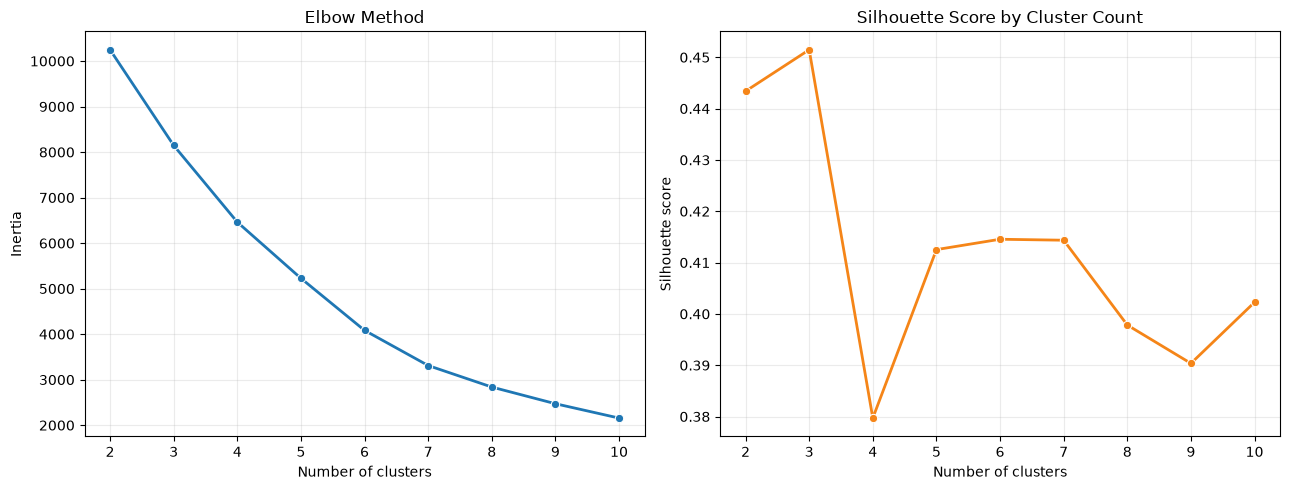

In [34]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.lineplot(
    data=cluster_evaluation,
    x="K",
    y="Inertia",
    marker="o",
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(K_VALUES))
axes[0].grid(alpha=0.25)

sns.lineplot(
    data=cluster_evaluation,
    x="K",
    y="SilhouetteScore",
    marker="o",
    linewidth=2,
    color="#F58518",
    ax=axes[1]
)

axes[1].set_title("Silhouette Score by Cluster Count")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(list(K_VALUES))
axes[1].grid(alpha=0.25)


plt.tight_layout()

plt.savefig(
    segmentation_figure_dir / "cluster_selection.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


In [35]:
best_silhouette_row = cluster_evaluation.loc[
    cluster_evaluation[
        "SilhouetteScore"
    ].idxmax()
]

print(
    "Highest silhouette K:",
    int(best_silhouette_row["K"])
)

print(
    "Highest silhouette score:",
    round(
        best_silhouette_row[
            "SilhouetteScore"
        ],
        4
    )
)

Highest silhouette K: 3
Highest silhouette score: 0.4515


In [36]:
cluster_evaluation[
    [
        "K",
        "Inertia",
        "InertiaReductionPercent",
        "SilhouetteScore",
        "SmallestClusterCustomers",
        "SmallestClusterPercent"
    ]
].round(3)

,K,Inertia,InertiaReductionPercent,SilhouetteScore,SmallestClusterCustomers,SmallestClusterPercent
0,2,10247.918,NaN,0.443,2729,46.737
1,3,8146.400,20.507,0.451,36,0.617
2,4,6461.447,20.683,0.380,20,0.343
3,5,5227.272,19.101,0.413,20,0.343
4,6,4083.182,21.887,0.415,1,0.017
5,7,3310.987,18.912,0.414,1,0.017
6,8,2838.226,14.279,0.398,1,0.017
7,9,2472.052,12.902,0.390,1,0.017
8,10,2156.673,12.758,0.402,1,0.017


In [37]:
CANDIDATE_K = 3

candidate_kmeans = KMeans(
    n_clusters=CANDIDATE_K,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

segmentation_df["KMeansCluster"] = (
    candidate_kmeans.fit_predict(
        X_processed
    )
)

In [38]:
cluster_sizes = (
    segmentation_df[
        "KMeansCluster"
    ]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

cluster_sizes["CustomerSharePercent"] = (
    cluster_sizes["Customers"]
    / cluster_sizes["Customers"].sum()
    * 100
)

cluster_sizes.round(2)

,Customers,CustomerSharePercent
KMeansCluster,,
0,3039,52.05
1,2764,47.34
2,36,0.62


In [39]:
cluster_profile = (
    segmentation_df
    .groupby("KMeansCluster")
    .agg(
        Customers=("KMeansCluster", "size"),

        AverageRecency=("Recency", "mean"),
        MedianRecency=("Recency", "median"),

        AverageFrequency=("Frequency", "mean"),
        MedianFrequency=("Frequency", "median"),

        TotalNetMonetary=("Monetary", "sum"),
        AverageNetMonetary=("Monetary", "mean"),
        MedianNetMonetary=("Monetary", "median"),

        AverageOrderValue=(
            "AverageOrderValue",
            "mean"
        ),

        AverageUnitsPurchased=(
            "UnitsPurchased",
            "mean"
        ),

        AverageCancellationRate=(
            "CancellationRatePercent",
            "mean"
        ),

        AverageRScore=("RScore", "mean"),
        AverageFScore=("FScore", "mean"),
        AverageMScore=("MScore", "mean")
    )
)

cluster_profile["CustomerSharePercent"] = (
    cluster_profile["Customers"]
    / cluster_profile["Customers"].sum()
    * 100
)

cluster_profile["RevenueSharePercent"] = (
    cluster_profile["TotalNetMonetary"]
    / cluster_profile["TotalNetMonetary"].sum()
    * 100
)

cluster_profile.round(2)

,Customers,AverageRecency,MedianRecency,AverageFrequency,MedianFrequency,TotalNetMonetary,AverageNetMonetary,MedianNetMonetary,AverageOrderValue,AverageUnitsPurchased,AverageCancellationRate,AverageRScore,AverageFScore,AverageMScore,CustomerSharePercent,RevenueSharePercent
KMeansCluster,,,,,,,,,,,,,,,,
0,3039,340.46,373.0,1.92,1.0,1848880.94,608.38,368.35,332.21,395.07,9.22,2.00,1.76,2.10,52.05,11.31
1,2764,49.62,27.0,9.73,7.0,10145266.19,3670.50,2079.18,380.70,2291.85,13.25,4.08,3.99,3.97,47.34,62.04
2,36,35.50,4.5,99.75,71.0,4357918.28,121053.29,72142.95,1709.99,71484.14,16.26,4.64,5.00,5.00,0.62,26.65


In [40]:
smallest_cluster = (
    cluster_sizes["Customers"].idxmin()
)

small_cluster_customers = (
    segmentation_df.loc[
        segmentation_df[
            "KMeansCluster"
        ].eq(smallest_cluster),
        [
            "Recency",
            "Frequency",
            "Monetary",
            "GrossMonetary",
            "AverageOrderValue",
            "UnitsPurchased",
            "UniqueProducts",
            "CancellationRatePercent",
            "RFMSegment"
        ]
    ]
    .sort_values(
        "Monetary",
        ascending=False
    )
)

print("Smallest cluster:", smallest_cluster)
print("Customers:", len(small_cluster_customers))

small_cluster_customers.head(40)

Smallest cluster: 2
Customers: 36


,Recency,Frequency,Monetary,GrossMonetary,AverageOrderValue,UnitsPurchased,UniqueProducts,CancellationRatePercent,RFMSegment
CustomerID,,,,,,,,,
18102,1,145,578408.640,579128.640,3993.990621,181173,382,1.360544,Champions
14646,2,144,523202.740,523987.340,3638.800972,365114,959,4.635762,Champions
14156,10,144,297775.010,298316.250,2071.640625,162498,1439,20.879121,Champions
14911,2,369,258522.430,259918.480,704.386125,141743,2507,20.129870,Champions
17450,9,49,233643.910,233675.910,4768.896122,80212,137,7.547170,Champions
13694,4,141,190391.500,193087.770,1369.416809,185933,894,9.615385,Champions
17511,3,59,168504.440,169626.870,2875.031695,115774,656,28.915663,Champions
12415,25,23,143107.020,143275.720,6229.379130,91126,495,14.814815,Champions
16684,5,53,141530.290,141955.550,2678.406604,101192,172,14.516129,Champions


In [41]:
rfm_cluster_comparison = pd.crosstab(
    segmentation_df["KMeansCluster"],
    segmentation_df["RFMSegment"],
    normalize="index"
).mul(100)

rfm_cluster_comparison.round(1)

RFMSegment,About to Sleep,At Risk,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Needs Attention,New Customers,Potential Loyalists,Promising
KMeansCluster,,,,,,,,,,
0,8.0,15.8,3.4,0.0,53.7,0.0,9.9,1.7,1.9,5.5
1,0.0,0.6,3.6,44.2,0.0,21.5,5.8,0.7,23.7,0.0
2,0.0,0.0,8.3,91.7,0.0,0.0,0.0,0.0,0.0,0.0


Evidence from the table:

Monetary value ranges up to approximately 578,409.
Several customers place more than 100 completed orders.
Units purchased and product variety are exceptionally high.
Most are Champions.
A few are Cannot Lose Them because their recency is high, such as 276 or 373 days.
Some have high cancellation rates, but their net monetary value remains substantial.

These customers likely represent wholesale-style or major commercial buyers.

In [42]:
FINAL_K = 3

Fit the final end-to-end pipeline

In [43]:
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

final_cluster_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            clone(preprocessing_pipeline)
        ),
        (
            "kmeans",
            KMeans(
                n_clusters=FINAL_K,
                init="k-means++",
                n_init=20,
                max_iter=500,
                random_state=42
            )
        )
    ]
)

segmentation_df["Cluster"] = (
    final_cluster_pipeline.fit_predict(
        X_raw
    )
)

In [44]:
assert segmentation_df["Cluster"].nunique() == 3
assert segmentation_df["Cluster"].notna().all()

segmentation_df["Cluster"].value_counts(
    sort=False
).sort_index()

Cluster
0    3039
1    2764
2      36
Name: count, dtype: int64

Create the final cluster profile

In [45]:
final_cluster_profile = (
    segmentation_df
    .groupby("Cluster")
    .agg(
        Customers=("Cluster", "size"),

        AverageRecency=("Recency", "mean"),
        MedianRecency=("Recency", "median"),

        AverageFrequency=("Frequency", "mean"),
        MedianFrequency=("Frequency", "median"),

        TotalNetMonetary=("Monetary", "sum"),
        AverageNetMonetary=("Monetary", "mean"),
        MedianNetMonetary=("Monetary", "median"),

        AverageOrderValue=(
            "AverageOrderValue",
            "mean"
        ),

        AverageUnitsPurchased=(
            "UnitsPurchased",
            "mean"
        ),

        AverageUniqueProducts=(
            "UniqueProducts",
            "mean"
        ),

        AverageCancellationRate=(
            "CancellationRatePercent",
            "mean"
        )
    )
)

final_cluster_profile[
    "CustomerSharePercent"
] = (
    final_cluster_profile["Customers"]
    / final_cluster_profile["Customers"].sum()
    * 100
)

final_cluster_profile[
    "RevenueSharePercent"
] = (
    final_cluster_profile["TotalNetMonetary"]
    / final_cluster_profile[
        "TotalNetMonetary"
    ].sum()
    * 100
)

final_cluster_profile.round(2)

,Customers,AverageRecency,MedianRecency,AverageFrequency,MedianFrequency,TotalNetMonetary,AverageNetMonetary,MedianNetMonetary,AverageOrderValue,AverageUnitsPurchased,AverageUniqueProducts,AverageCancellationRate,CustomerSharePercent,RevenueSharePercent
Cluster,,,,,,,,,,,,,,
0,3039,340.46,373.0,1.92,1.0,1848880.94,608.38,368.35,332.21,395.07,33.73,9.22,52.05,11.31
1,2764,49.62,27.0,9.73,7.0,10145266.19,3670.50,2079.18,380.70,2291.85,128.74,13.25,47.34,62.04
2,36,35.50,4.5,99.75,71.0,4357918.28,121053.29,72142.95,1709.99,71484.14,548.25,16.26,0.62,26.65


Recover the approximate raw cluster centres

In [46]:
transformed_centres = (
    final_cluster_pipeline
    .named_steps["kmeans"]
    .cluster_centers_
)

raw_centres = (
    final_cluster_pipeline
    .named_steps["preprocessing"]
    .inverse_transform(
        transformed_centres
    )
)

cluster_centres = pd.DataFrame(
    raw_centres,
    columns=clustering_features
)

cluster_centres.index.name = "Cluster"

cluster_centres.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,273.17,1.62,479.69
1,29.54,6.38,3051.43
2,8.94,62.64,107873.78


Cluster interpretation
Cluster	Name	Customers	Revenue share	Interpretation
0	Dormant / Low Engagement	3,039 (52.05%)	11.31%	Infrequent, low-value customers who have not purchased recently
1	Active Core Customers	2,764 (47.34%)	62.04%	Recent, repeat customers generating most revenue
2	VIP / High-Value Customers	36 (0.62%)	26.65%	Extremely frequent, high-volume and high-value strategic customers

Assign Cluster names

In [47]:
cluster_name_map = {
    0: "Dormant / Low Engagement",
    1: "Active Core Customers",
    2: "VIP / High Value"
}

segmentation_df["ClusterName"] = (
    segmentation_df["Cluster"]
    .map(cluster_name_map)
)

assert segmentation_df[
    "ClusterName"
].notna().all()

In [48]:
final_cluster_profile_named = (
    final_cluster_profile
    .reset_index()
)

final_cluster_profile_named[
    "ClusterName"
] = (
    final_cluster_profile_named[
        "Cluster"
    ].map(cluster_name_map)
)

final_cluster_profile_named = (
    final_cluster_profile_named[
        [
            "Cluster",
            "ClusterName",
            "Customers",
            "CustomerSharePercent",
            "AverageRecency",
            "MedianRecency",
            "AverageFrequency",
            "MedianFrequency",
            "TotalNetMonetary",
            "AverageNetMonetary",
            "MedianNetMonetary",
            "RevenueSharePercent",
            "AverageOrderValue",
            "AverageCancellationRate"
        ]
    ]
)

final_cluster_profile_named.round(2)

,Cluster,ClusterName,Customers,CustomerSharePercent,AverageRecency,MedianRecency,AverageFrequency,MedianFrequency,TotalNetMonetary,AverageNetMonetary,MedianNetMonetary,RevenueSharePercent,AverageOrderValue,AverageCancellationRate
0,0,Dormant / Low Engagement,3039,52.05,340.46,373.0,1.92,1.0,1848880.94,608.38,368.35,11.31,332.21,9.22
1,1,Active Core Customers,2764,47.34,49.62,27.0,9.73,7.0,10145266.19,3670.50,2079.18,62.04,380.70,13.25
2,2,VIP / High Value,36,0.62,35.50,4.5,99.75,71.0,4357918.28,121053.29,72142.95,26.65,1709.99,16.26


Business actions
Dormant / Low Engagement: low-cost win-back campaigns, reminders and reactivation offers.
Active Core Customers: loyalty rewards, cross-selling and repeat-purchase recommendations.
VIP / High Value: dedicated account treatment, priority inventory, early access and individual cancellation monitoring.

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare customer-share and revenue-share data
cluster_business_share = (
    final_cluster_profile
    .reset_index()[
        [
            "Cluster",
            "CustomerSharePercent",
            "RevenueSharePercent"
        ]
    ]
)

cluster_business_share["CustomerSegment"] = (
    cluster_business_share["Cluster"]
    .map(cluster_name_map)
)

cluster_business_share_long = (
    cluster_business_share
    .melt(
        id_vars=["Cluster", "CustomerSegment"],
        value_vars=[
            "CustomerSharePercent",
            "RevenueSharePercent"
        ],
        var_name="ShareType",
        value_name="SharePercent"
    )
)

cluster_business_share_long["ShareType"] = (
    cluster_business_share_long["ShareType"]
    .map({
        "CustomerSharePercent": "Customer Share",
        "RevenueSharePercent": "Revenue Share"
    })
)

cluster_business_share_long

,Cluster,CustomerSegment,ShareType,SharePercent
0,0,Dormant / Low Engagement,Customer Share,52.046583
1,1,Active Core Customers,Customer Share,47.336873
2,2,VIP / High Value,Customer Share,0.616544
3,0,Dormant / Low Engagement,Revenue Share,11.306712
4,1,Active Core Customers,Revenue Share,62.042720
5,2,VIP / High Value,Revenue Share,26.650568


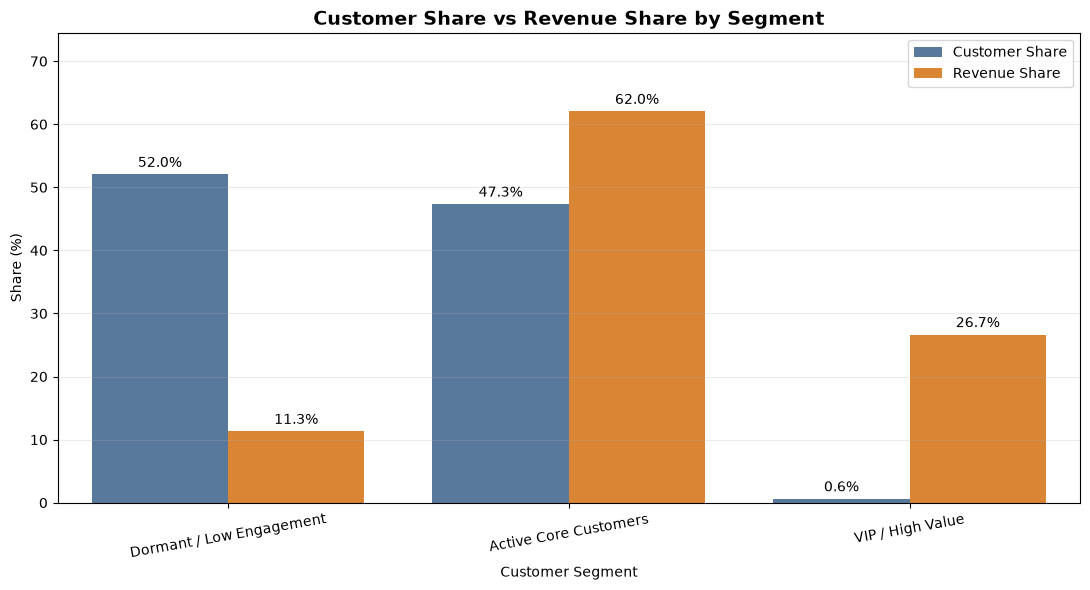

In [50]:
segment_order = [
    cluster_name_map[0],
    cluster_name_map[1],
    cluster_name_map[2]
]

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=cluster_business_share_long,
    x="CustomerSegment",
    y="SharePercent",
    hue="ShareType",
    order=segment_order,
    palette={
        "Customer Share": "#4C78A8",
        "Revenue Share": "#F58518"
    },
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set_title(
    "Customer Share vs Revenue Share by Segment",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Customer Segment")
ax.set_ylabel("Share (%)")
ax.set_ylim(
    0,
    cluster_business_share_long["SharePercent"].max() * 1.20
)

ax.tick_params(axis="x", rotation=10)
ax.legend(title="")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig.savefig(
    segmentation_figure_dir / "cluster_business_share.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Comparing K-Means with RFM segments

In [51]:
rfm_cluster_counts = pd.crosstab(
    segmentation_df["ClusterName"],
    segmentation_df["RFMSegment"]
)

rfm_cluster_percent = pd.crosstab(
    segmentation_df["ClusterName"],
    segmentation_df["RFMSegment"],
    normalize="index"
).mul(100)

rfm_cluster_counts

RFMSegment,About to Sleep,At Risk,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Needs Attention,New Customers,Potential Loyalists,Promising
ClusterName,,,,,,,,,,
Active Core Customers,0,16,99,1222,0,593,160,18,656,0
Dormant / Low Engagement,242,481,104,0,1632,1,300,53,59,167
VIP / High Value,0,0,3,33,0,0,0,0,0,0


In [52]:
rfm_cluster_percent.round(1)

RFMSegment,About to Sleep,At Risk,Cannot Lose Them,Champions,Hibernating,Loyal Customers,Needs Attention,New Customers,Potential Loyalists,Promising
ClusterName,,,,,,,,,,
Active Core Customers,0.0,0.6,3.6,44.2,0.0,21.5,5.8,0.7,23.7,0.0
Dormant / Low Engagement,8.0,15.8,3.4,0.0,53.7,0.0,9.9,1.7,1.9,5.5
VIP / High Value,0.0,0.0,8.3,91.7,0.0,0.0,0.0,0.0,0.0,0.0


Visualize K-Means vs RFM segments

In [53]:
cluster_order = [
    "Dormant / Low Engagement",
    "Active Core Customers",
    "VIP / High Value"
]

rfm_segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "New Customers",
    "Promising",
    "Needs Attention",
    "About to Sleep",
    "At Risk",
    "Cannot Lose Them",
    "Hibernating"
]

rfm_cluster_percent = pd.crosstab(
    segmentation_df["ClusterName"],
    segmentation_df["RFMSegment"],
    normalize="index"
).mul(100)

rfm_cluster_percent = (
    rfm_cluster_percent
    .reindex(
        index=cluster_order,
        columns=rfm_segment_order,
        fill_value=0
    )
)

rfm_cluster_percent.round(1)

RFMSegment,Champions,Loyal Customers,Potential Loyalists,New Customers,Promising,Needs Attention,About to Sleep,At Risk,Cannot Lose Them,Hibernating
ClusterName,,,,,,,,,,
Dormant / Low Engagement,0.0,0.0,1.9,1.7,5.5,9.9,8.0,15.8,3.4,53.7
Active Core Customers,44.2,21.5,23.7,0.7,0.0,5.8,0.0,0.6,3.6,0.0
VIP / High Value,91.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.3,0.0


In [54]:
assert np.allclose(
    rfm_cluster_percent.sum(axis=1),
    100
)

print("RFM-cluster comparison validated.")

RFM-cluster comparison validated.


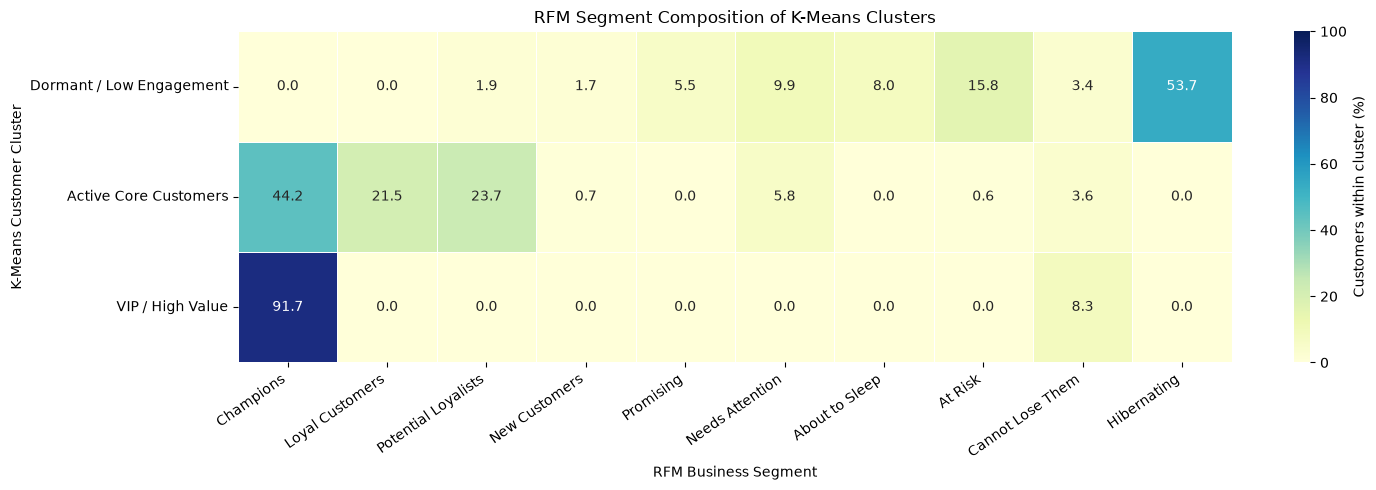

In [55]:
plt.figure(figsize=(15, 5))

sns.heatmap(
    rfm_cluster_percent,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={
        "label": "Customers within cluster (%)"
    }
)

plt.title(
    "RFM Segment Composition of K-Means Clusters"
)
plt.xlabel("RFM Business Segment")
plt.ylabel("K-Means Customer Cluster")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    segmentation_figure_dir / "rfm_cluster_heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [56]:
dominant_rfm_by_cluster = pd.DataFrame({
    "DominantRFMSegment": (
        rfm_cluster_percent.idxmax(axis=1)
    ),
    "DominantSegmentPercent": (
        rfm_cluster_percent.max(axis=1)
    )
})

dominant_rfm_by_cluster.round(2)

,DominantRFMSegment,DominantSegmentPercent
ClusterName,,
Dormant / Low Engagement,Hibernating,53.70
Active Core Customers,Champions,44.21
VIP / High Value,Champions,91.67


In [57]:
rfm_cluster_counts = pd.crosstab(
    segmentation_df["ClusterName"],
    segmentation_df["RFMSegment"]
).reindex(
    index=cluster_order,
    columns=rfm_segment_order,
    fill_value=0
)

rfm_cluster_counts

RFMSegment,Champions,Loyal Customers,Potential Loyalists,New Customers,Promising,Needs Attention,About to Sleep,At Risk,Cannot Lose Them,Hibernating
ClusterName,,,,,,,,,,
Dormant / Low Engagement,0,1,59,53,167,300,242,481,104,1632
Active Core Customers,1222,593,656,18,0,160,0,16,99,0
VIP / High Value,33,0,0,0,0,0,0,0,3,0


In [58]:
from sklearn.decomposition import PCA

X_final_processed = (
    final_cluster_pipeline
    .named_steps["preprocessing"]
    .transform(X_raw)
)

pca = PCA(
    n_components=2,
    random_state=42
)

pca_coordinates = pca.fit_transform(
    X_final_processed
)

In [59]:
pca_df = pd.DataFrame(
    pca_coordinates,
    index=segmentation_df.index,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = (
    segmentation_df["Cluster"]
)

pca_df["ClusterName"] = (
    segmentation_df["ClusterName"]
)

print(
    "PC1 explained variance:",
    f"{pca.explained_variance_ratio_[0]:.2%}"
)

print(
    "PC2 explained variance:",
    f"{pca.explained_variance_ratio_[1]:.2%}"
)

print(
    "Total explained variance:",
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

PC1 explained variance: 63.38%
PC2 explained variance: 23.67%
Total explained variance: 87.05%


In [60]:
transformed_cluster_centres = (
    final_cluster_pipeline
    .named_steps["kmeans"]
    .cluster_centers_
)

pca_cluster_centres = pca.transform(
    transformed_cluster_centres
)

pca_centres_df = pd.DataFrame(
    pca_cluster_centres,
    columns=["PC1", "PC2"]
)

pca_centres_df["Cluster"] = (
    range(FINAL_K)
)

pca_centres_df["ClusterName"] = (
    pca_centres_df["Cluster"]
    .map(cluster_name_map)
)

pca_centres_df

,PC1,PC2,Cluster,ClusterName
0,-1.032639,0.263011,0,Dormant / Low Engagement
1,1.062000,-0.356970,1,Active Core Customers
2,6.215745,5.032697,2,VIP / High Value


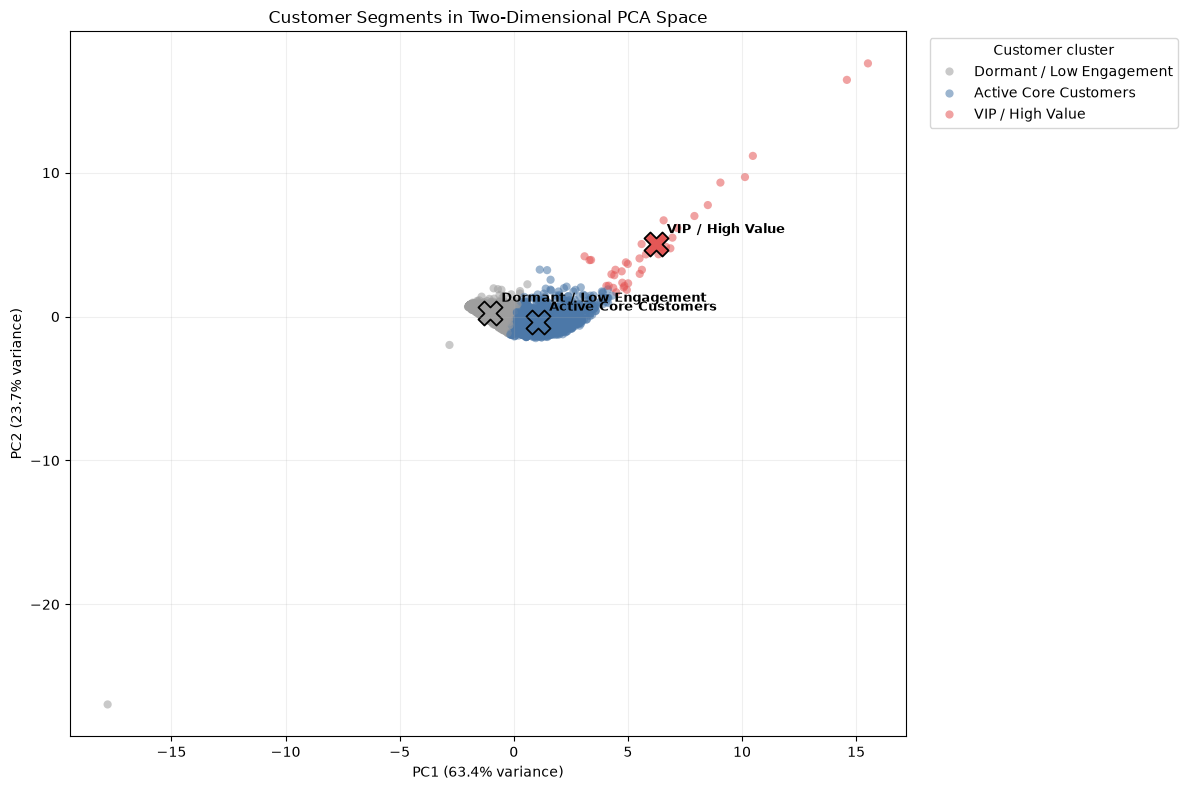

In [61]:
cluster_order = [
    "Dormant / Low Engagement",
    "Active Core Customers",
    "VIP / High Value"
]

cluster_palette = {
    "Dormant / Low Engagement": "#9E9E9E",
    "Active Core Customers": "#4C78A8",
    "VIP / High Value": "#E45756"
}

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="ClusterName",
    hue_order=cluster_order,
    palette=cluster_palette,
    alpha=0.55,
    s=35,
    linewidth=0,
    ax=ax
)

for _, row in pca_centres_df.iterrows():
    ax.scatter(
        row["PC1"],
        row["PC2"],
        marker="X",
        s=300,
        color=cluster_palette[
            row["ClusterName"]
        ],
        edgecolor="black",
        linewidth=1.3
    )

    ax.annotate(
        row["ClusterName"],
        (row["PC1"], row["PC2"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Customer Segments in Two-Dimensional PCA Space"
)

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)"
)

ax.grid(alpha=0.2)

ax.legend(
    title="Customer cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

figure_folder = (
    project_root
    / "reports"
    / "figures"
    / "customer_segmentation"
)

figure_folder.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    figure_folder / "customer_clusters.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [62]:
import plotly.express as px
import plotly.graph_objects as go

In [63]:
rfm_3d = pd.DataFrame(
    X_final_processed,
    index=segmentation_df.index,
    columns=[
        "TransformedRecency",
        "TransformedFrequency",
        "TransformedMonetary"
    ]
)

rfm_3d["ClusterName"] = (
    segmentation_df["ClusterName"]
)

# Raw values for hover information
rfm_3d["Recency"] = X_raw["Recency"]
rfm_3d["Frequency"] = X_raw["Frequency"]
rfm_3d["Monetary"] = X_raw["Monetary"]

rfm_3d.index.name = "CustomerID"
rfm_3d = rfm_3d.reset_index()

In [64]:
cluster_palette = {
    "Dormant / Low Engagement": "#9E9E9E",
    "Active Core Customers": "#4C78A8",
    "VIP / High Value": "#E45756"
}

fig = px.scatter_3d(
    rfm_3d,
    x="TransformedRecency",
    y="TransformedFrequency",
    z="TransformedMonetary",
    color="ClusterName",
    color_discrete_map=cluster_palette,
    hover_name="CustomerID",
    hover_data={
        "Recency": ":.0f",
        "Frequency": ":.0f",
        "Monetary": ":,.2f",
        "TransformedRecency": False,
        "TransformedFrequency": False,
        "TransformedMonetary": False
    },
    title="Customer Segments in Transformed RFM Space"
)

fig.update_traces(
    marker={
        "size": 3,
        "opacity": 0.60
    }
)

In [65]:
centres_3d = pd.DataFrame(
    final_cluster_pipeline
    .named_steps["kmeans"]
    .cluster_centers_,
    columns=[
        "TransformedRecency",
        "TransformedFrequency",
        "TransformedMonetary"
    ]
)

centres_3d["Cluster"] = range(FINAL_K)

centres_3d["ClusterName"] = (
    centres_3d["Cluster"]
    .map(cluster_name_map)
)

fig.add_trace(
    go.Scatter3d(
        x=centres_3d["TransformedRecency"],
        y=centres_3d["TransformedFrequency"],
        z=centres_3d["TransformedMonetary"],
        mode="markers+text",
        text=centres_3d["ClusterName"],
        textposition="top center",
        name="Cluster centres",
        marker={
            "size": 9,
            "symbol": "diamond",
            "color": [
                cluster_palette[name]
                for name in centres_3d["ClusterName"]
            ],
            "line": {
                "color": "black",
                "width": 2
            }
        }
    )
)

In [66]:
fig.update_layout(
    height=750,
    scene={
        "xaxis_title": "Transformed Recency",
        "yaxis_title": "Transformed Frequency",
        "zaxis_title": "Transformed Monetary"
    },
    legend_title="Customer cluster",
    margin={
        "l": 0,
        "r": 0,
        "b": 0,
        "t": 50
    }
)


fig.show()



In [67]:
interactive_3d_file = (
    segmentation_figure_dir
    / "customer_clusters_3d.html"
)

fig.write_html(
    interactive_3d_file,
    include_plotlyjs=True,
    full_html=True
)

print("Interactive 3D plot saved to:")
print(interactive_3d_file)

fig.show()

Interactive 3D plot saved to:
c:\Github\retail-financial-intelligence\reports\figures\customer_segmentation\customer_clusters_3d.html


Validate cluster stability
Run the stability test

In [68]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score
)

reference_labels = (
    segmentation_df["Cluster"]
    .to_numpy()
)

stability_seeds = [
    0,
    7,
    21,
    99,
    123
]

stability_records = []

for seed in stability_seeds:
    stability_model = KMeans(
        n_clusters=FINAL_K,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=seed
    )

    stability_labels = (
        stability_model.fit_predict(
            X_final_processed
        )
    )

    ari_score = adjusted_rand_score(
        reference_labels,
        stability_labels
    )

    silhouette = silhouette_score(
        X_final_processed,
        stability_labels,
        sample_size=(
            5000
            if len(X_final_processed) > 5000
            else None
        ),
        random_state=42
    )

    cluster_counts = np.bincount(
        stability_labels
    )

    stability_records.append({
        "RandomSeed": seed,
        "AdjustedRandIndex": ari_score,
        "SilhouetteScore": silhouette,
        "Inertia": stability_model.inertia_,
        "SmallestClusterCustomers": int(
            cluster_counts.min()
        )
    })

cluster_stability = pd.DataFrame(
    stability_records
)

cluster_stability.round(4)

,RandomSeed,AdjustedRandIndex,SilhouetteScore,Inertia,SmallestClusterCustomers
0,0,1.0000,0.4515,8146.3165,36
1,7,1.0000,0.4515,8146.3165,36
2,21,0.9853,0.4503,8165.7747,22
3,99,1.0000,0.4515,8146.3165,36
4,123,1.0000,0.4515,8146.3165,36


In [69]:
stability_summary = pd.Series({
    "Minimum ARI": (
        cluster_stability[
            "AdjustedRandIndex"
        ].min()
    ),
    "Average ARI": (
        cluster_stability[
            "AdjustedRandIndex"
        ].mean()
    ),
    "Maximum ARI": (
        cluster_stability[
            "AdjustedRandIndex"
        ].max()
    ),
    "Average silhouette": (
        cluster_stability[
            "SilhouetteScore"
        ].mean()
    ),
    "Minimum small-cluster size": (
        cluster_stability[
            "SmallestClusterCustomers"
        ].min()
    ),
    "Maximum small-cluster size": (
        cluster_stability[
            "SmallestClusterCustomers"
        ].max()
    )
})

stability_summary.round(4)

Minimum ARI                    0.9853
Average ARI                    0.9971
Maximum ARI                    1.0000
Average silhouette             0.4512
Minimum small-cluster size    22.0000
Maximum small-cluster size    36.0000
dtype: float64

In [70]:
final_silhouette = silhouette_score(
    X_final_processed,
    segmentation_df["Cluster"],
    sample_size=(
        5000
        if len(X_final_processed) > 5000
        else None
    ),
    random_state=42
)

print(
    "Final model silhouette:",
    round(final_silhouette, 4)
)

Final model silhouette: 0.4515


Final segmentation validation

In [71]:
segmentation_validation = pd.Series({
    "Customer rows preserved": (
        len(segmentation_df) == len(X_raw)
    ),
    "Three clusters created": (
        segmentation_df["Cluster"].nunique()
        == FINAL_K
    ),
    "No missing cluster labels": (
        segmentation_df["Cluster"].notna().all()
    ),
    "No missing cluster names": (
        segmentation_df["ClusterName"].notna().all()
    ),
    "No missing RFM segments": (
        segmentation_df["RFMSegment"].notna().all()
    ),
    "R scores valid": (
        segmentation_df["RScore"]
        .between(1, 5).all()
    ),
    "F scores valid": (
        segmentation_df["FScore"]
        .between(1, 5).all()
    ),
    "M scores valid": (
        segmentation_df["MScore"]
        .between(1, 5).all()
    ),
    "Cluster customer shares total 100": (
        np.isclose(
            final_cluster_profile_named[
                "CustomerSharePercent"
            ].sum(),
            100
        )
    ),
    "Cluster revenue reconciles": (
        np.isclose(
            final_cluster_profile_named[
                "TotalNetMonetary"
            ].sum(),
            segmentation_df["Monetary"].sum()
        )
    ),
    "Minimum stability above 0.90": (
        cluster_stability[
            "AdjustedRandIndex"
        ].min() >= 0.90
    )
})

segmentation_validation

Customer rows preserved              True
Three clusters created               True
No missing cluster labels            True
No missing cluster names             True
No missing RFM segments              True
R scores valid                       True
F scores valid                       True
M scores valid                       True
Cluster customer shares total 100    True
Cluster revenue reconciles           True
Minimum stability above 0.90         True
dtype: bool

In [72]:
assert segmentation_validation.all()

print("All segmentation validations passed.")

All segmentation validations passed.


In [73]:
segmentation_output_folder = (
    project_root
    / "data"
    / "processed"
    / "customer_segmentation"
)

model_output_folder = (
    project_root
    / "models"
)

segmentation_output_folder.mkdir(
    parents=True,
    exist_ok=True
)

model_output_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [74]:
customer_segments_export = (
    segmentation_df
    .reset_index()
)

customer_segments_export.head()

,CustomerID,FirstPurchase,LastPurchase,Frequency,GrossMonetary,UnitsPurchased,UniqueProducts,Recency,CustomerTenureDays,AverageOrderValue,...,Monetary,RScore,FScore,MScore,RFMCode,RFMTotal,RFMSegment,KMeansCluster,Cluster,ClusterName
0,12346,2010-03-02 13:08:00,2010-06-28 13:53:00,2,169.36,24,24,530,648,84.68000,...,169.36,1,2,1,121,4,Hibernating,0,0,Dormant / Low Engagement
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,4921.53,2967,126,3,405,615.19125,...,4921.53,5,4,5,545,14,Champions,1,1,Active Core Customers
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,1658.40,2704,24,76,439,331.68000,...,1658.40,3,4,4,344,11,Loyal Customers,1,1,Active Core Customers
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,3,3678.69,1621,137,19,590,1226.23000,...,3654.54,5,3,5,535,13,Potential Loyalists,1,1,Active Core Customers
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,196,16,311,311,294.40000,...,294.40,2,1,2,212,5,Hibernating,0,0,Dormant / Low Engagement


In [75]:
customer_segments_export.to_csv(
    segmentation_output_folder
    / "customer_segments.csv.gz",
    index=False,
    compression="gzip"
)

final_cluster_profile_named.to_csv(
    segmentation_output_folder
    / "cluster_profiles.csv",
    index=False
)

rfm_segment_summary.to_csv(
    segmentation_output_folder
    / "rfm_segment_summary.csv",
    index=False
)

rfm_cluster_counts.to_csv(
    segmentation_output_folder
    / "rfm_cluster_counts.csv"
)

rfm_cluster_percent.to_csv(
    segmentation_output_folder
    / "rfm_cluster_percent.csv"
)

cluster_evaluation.to_csv(
    segmentation_output_folder
    / "cluster_evaluation.csv",
    index=False
)

cluster_stability.to_csv(
    segmentation_output_folder
    / "cluster_stability.csv",
    index=False
)

cluster_centres.to_csv(
    segmentation_output_folder
    / "cluster_centres.csv"
)

In [76]:
import joblib

model_file = (
    model_output_folder
    / "customer_segmentation_pipeline.joblib"
)

joblib.dump(
    final_cluster_pipeline,
    model_file
)

print("Model saved to:", model_file)

Model saved to: c:\Github\retail-financial-intelligence\models\customer_segmentation_pipeline.joblib


In [77]:
loaded_pipeline = joblib.load(
    model_file
)

loaded_predictions = (
    loaded_pipeline.predict(X_raw)
)

saved_model_ari = adjusted_rand_score(
    segmentation_df["Cluster"],
    loaded_predictions
)

print(
    "Saved model ARI:",
    round(saved_model_ari, 4)
)

assert np.isclose(saved_model_ari, 1.0)

Saved model ARI: 1.0


## Customer Segmentation — Final Findings

### Executive Summary

RetailIQ’s customer segmentation analysis evaluated 5,839 customers using Recency, Frequency and net Monetary value. The RFM variables were transformed using Yeo–Johnson transformation, standardized and clustered using KMeans.

The final model identified three commercially meaningful customer groups:

Customer segment	Customers	Customer share	Revenue share
Dormant / Low Engagement	3,039	52.05%	11.31%
Active Core Customers	2,764	47.34%	62.04%
VIP / High Value	36	0.62%	26.65%

The analysis shows a strong concentration of value. Active Core and VIP customers together represent 47.96% of customers but generate 88.69% of net customer revenue. The VIP segment alone contributes more than one-quarter of revenue despite containing only 36 customers.

The principal business opportunity is therefore to protect VIP relationships, develop Active Core customers toward higher value and use selective win-back campaigns for Dormant customers. The final three-cluster solution achieved a silhouette score of 0.4515 and remained highly consistent across multiple random seeds.

### Method

Customer segmentation was performed using Recency, Frequency and net Monetary value. Exact reversal sales were excluded from behavioural features, while cancellations were retained when calculating net customer value.

The RFM variables were transformed using Yeo-Johnson, standardized and clustered using K-Means. RFM scores from 1 to 5 were also created separately to provide explainable business segments.

### Model selection

Three clusters were selected based on statistical quality, stability and business usefulness.

* Final silhouette score: **0.4515**
* Minimum Adjusted Rand Index across stability tests: **0.9853**
* Average Adjusted Rand Index: **0.9971**
* Four of five random-seed tests produced identical clusters

These results indicate that the three-cluster solution is reasonably separated and highly stable.

### Cluster 0 — Dormant / Low Engagement

* Customers: **3,039**
* Customer share: **52.05%**
* Revenue share: **11.31%**
* Median recency: **373 days**
* Median frequency: **1 order**
* Median net monetary value: **368.35**

This is the largest customer group but contributes a relatively small share of revenue. Most customers purchased infrequently and have not purchased recently.

**Recommended actions:** low-cost reactivation campaigns, personalized reminders, limited win-back incentives and suppression of unresponsive customers after testing.

### Cluster 1 — Active Core Customers

* Customers: **2,764**
* Customer share: **47.34%**
* Revenue share: **62.04%**
* Median recency: **27 days**
* Median frequency: **7 orders**
* Median net monetary value: **2,079.18**

This cluster represents the main active customer base and generates most of the company’s customer revenue.

**Recommended actions:** loyalty benefits, personalized cross-selling, repeat-purchase recommendations, early product access and retention monitoring.

### Cluster 2 — VIP / High Value

* Customers: **36**
* Customer share: **0.62%**
* Revenue share: **26.65%**
* Median recency: **4.5 days**
* Median frequency: **71 orders**
* Median net monetary value: **72,142.95**

A very small group generates more than one-quarter of net customer revenue. Their exceptionally high order frequency, volume and monetary value suggest strategic or wholesale-style purchasing behaviour.

**Recommended actions:** dedicated account treatment, priority inventory allocation, proactive service, customized commercial offers and individual cancellation monitoring.

The high revenue concentration also creates dependency risk. Losing only a few customers from this group could materially affect revenue.

### RFM and K-Means interpretation

K-Means provides three broad data-driven customer groups, while RFM scoring provides more detailed business-action categories such as Champions, Loyal Customers, At Risk and Hibernating.

The two methods are complementary:

* K-Means summarizes overall customer structure.
* RFM segments identify specific retention and marketing actions.
* Customers within the VIP cluster can still require different treatment depending on whether they are Champions or Cannot Lose Them.
* Customers in the dormant cluster can be prioritized using their previous monetary contribution.

## Cluster Selection

![Elbow and silhouette analysis](figures/customer_segmentation/cluster_selection.png)

The silhouette score supports three clusters as the most balanced and interpretable solution.

## Customer and Revenue Contribution

![Customer and revenue share by cluster](figures/customer_segmentation/cluster_business_share.png)

The VIP segment represents only 0.62% of customers but generates 26.65% of net revenue.

## RFM and KMeans Comparison

![RFM and KMeans comparison](figures/customer_segmentation/rfm_cluster_heatmap.png)

RFM provides rule-based customer labels, while KMeans identifies behavioural groups from continuous RFM variables.

## Customer Cluster Visualization

![Three-dimensional customer clusters](figures/customer_segmentation/customer_clusters_3d.png)

[Open the interactive 3D visualization](figures/customer_segmentation/customer_clusters_3d.html)

### Business Recommendations
VIP / High Value

The 36 VIP customers generate 26.65% of customer revenue, making them commercially important despite representing only 0.62% of the customer base.

Recommended actions:

Assign priority service and proactive account management.
Provide early access to new products and high-demand inventory.
Offer personalized product recommendations based on purchase history.
Monitor changes in order frequency, recency and cancellation activity.
Avoid broad discounts that may reduce margin without increasing retention.
Track revenue concentration risk because losing a few VIP customers could materially affect total revenue.
Active Core Customers

Active Core Customers account for 47.34% of customers and 62.04% of revenue. This segment is the company’s largest dependable revenue base.

Recommended actions:

Introduce loyalty rewards based on repeat purchases or cumulative spend.
Use cross-selling and product-bundle recommendations to increase basket value.
Send replenishment or reorder reminders based on purchase intervals.
Identify high-potential customers approaching VIP-level frequency or monetary value.
Use targeted promotions instead of uniform discounts.
Encourage customers to explore additional product categories.
Dormant / Low Engagement

Dormant customers represent 52.05% of customers but only 11.31% of revenue. Their high recency and low order frequency indicate limited recent engagement.

Recommended actions:

Run controlled win-back campaigns with time-limited offers.
Personalize messages using previously purchased products or categories.
Separate historically valuable dormant customers from one-time low-value buyers.
Test campaigns on small customer groups before expanding them.
Compare campaign revenue with discount and communication costs.
Reduce repeated marketing activity for customers who remain inactive after several attempts.

Ongoing Segment Management

Customer segments should be recalculated regularly because customer behaviour changes over time.

RetailIQ should monitor:

Customer movement between segments.
Segment-level revenue and customer share.
Changes in average recency and order frequency.
Cancellation rates by customer segment.
VIP revenue concentration.
Conversion from Active Core to VIP.
Reactivation rates among Dormant customers.

The segmentation results should guide marketing and customer-management decisions, but campaign effectiveness should be validated through controlled experiments or A/B testing.

Model Stability

The number of clusters was evaluated using both the elbow method and silhouette score for values of (k) from 2 to 10. The three-cluster solution produced the highest silhouette score while maintaining interpretable and commercially meaningful customer groups.

The final model was tested using random seeds 0, 7, 21, 99 and 123.

Stability measure	Result
Final silhouette score	0.4515
Average silhouette score	0.4512
Minimum Adjusted Rand Index	0.9853
Average Adjusted Rand Index	0.9971
Maximum Adjusted Rand Index	1.0000
Final VIP cluster size	36 customers
Smallest cluster range across tests	22–36 customers

Four of the five tested seeds reproduced exactly the same clustering assignment, with an Adjusted Rand Index of 1.0000. The remaining seed produced a very similar solution with an Adjusted Rand Index of 0.9853.

These results indicate that the selected segmentation is highly stable with respect to KMeans initialization. The small VIP cluster is therefore not simply the result of one random model run. It reflects a persistent group of unusually frequent and high-value customers.

However, initialization stability does not guarantee that customer behaviour will remain unchanged. The model should be monitored over time for changes in cluster size, cluster centres, silhouette score and business interpretation.

### Limitations

The analysis is based only on observed transaction history. The first recorded purchase may not represent the customer’s true acquisition date. Customer demographics, acquisition channels, product costs and profit margins are unavailable.

The VIP/wholesale interpretation is inferred from transaction volume and must be validated with business information. Cluster labels are business interpretations; numerical cluster IDs themselves have no inherent meaning.

### Conclusion

RetailIQ has three commercially distinct customer groups: a large dormant population, an active core generating most revenue and a very small high-value group with disproportionate financial importance.

The recommended strategy is to reactivate selected dormant customers, retain and grow active core customers, and protect high-value relationships through proactive account management.


In [81]:
from pathlib import Path
import sys
import importlib


def find_project_root(start_path: Path) -> Path:
    """Find the nearest parent directory containing src."""

    candidates = [
        start_path,
        *start_path.parents
    ]

    for candidate in candidates:
        if (candidate / "src").is_dir():
            return candidate

    # Explicit fallback for your project location
    fallback = Path(
        r"C:\Github\retail-financial-intelligence"
    )

    if (fallback / "src").is_dir():
        return fallback

    raise FileNotFoundError(
        "Could not locate the project folder "
        "containing the src directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

importlib.invalidate_caches()

print("Working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Working directory: c:\Github\retail-financial-intelligence\notebooks
Project root: c:\Github\retail-financial-intelligence
src exists: True


In [83]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(
    r"C:\Github\retail-financial-intelligence"
)

master_file = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "retailiq_cleaned_master.csv.gz"
)

if not master_file.exists():
    raise FileNotFoundError(
        f"Master dataset not found: {master_file}"
    )

master_df = pd.read_csv(
    master_file,
    compression="gzip",
    parse_dates=["InvoiceDate"],
    dtype={
        "Invoice": "string",
        "StockCode": "string",
        "StockCodeNormalized": "string",
        "CustomerID": "Int64",
    },
    low_memory=False,
)

print("Master shape:", master_df.shape)
print("Master file:", master_file)
print("Customers:", master_df["CustomerID"].nunique())

Master shape: (1033036, 29)
Master file: C:\Github\retail-financial-intelligence\data\processed\retailiq_cleaned_master.csv.gz
Customers: 5942


In [86]:
import importlib
import src.features.customer_features as customer_feature_module

importlib.reload(customer_feature_module)

(
    all_customer_features,
    customer_segmentation_features,
) = customer_feature_module.build_customer_features(
    master_df
)

print(
    "All customers:",
    len(all_customer_features)
)

print(
    "Segmentation customers:",
    len(customer_segmentation_features)
)

print(
    "Excluded reversal-only customers:",
    len(all_customer_features)
    - len(customer_segmentation_features)
)

All customers: 5942
Segmentation customers: 5839
Excluded reversal-only customers: 103


In [91]:
import importlib
import src.features.customer_features as customer_feature_module

importlib.reload(customer_feature_module)

(
    all_customer_features,
    customer_segmentation_features,
) = customer_feature_module.build_customer_features(
    master_df
)

population_summary = pd.Series(
    {
        "All identified customers": (
            master_df["CustomerID"].nunique()
        ),
        "Customers with valid sales": (
            len(all_customer_features)
        ),
        "Segmentation customers": (
            len(customer_segmentation_features)
        ),
        "No-valid-sale customers": (
            master_df["CustomerID"].nunique()
            - len(all_customer_features)
        ),
        "Reversal-only customers": (
            len(all_customer_features)
            - len(customer_segmentation_features)
        ),
    }
)

population_summary

All identified customers      5942
Customers with valid sales    5852
Segmentation customers        5839
No-valid-sale customers         90
Reversal-only customers         13
dtype: int64

In [92]:
import numpy as np
import pandas as pd

expected_customer_features = pd.DataFrame(
    {
        "CustomerID": [
            18102,
            14646,
            14156,
            14911
        ],
        "Recency": [1, 2, 10, 2],
        "Frequency": [145, 144, 144, 369],
        "Monetary": [
            578408.640,
            523202.740,
            297775.010,
            258522.430
        ],
        "GrossMonetary": [
            579128.640,
            523987.340,
            298316.250,
            259918.480
        ],
        "AverageOrderValue": [
            3993.990621,
            3638.800972,
            2071.640625,
            704.386125
        ],
        "UnitsPurchased": [
            181173,
            365114,
            162498,
            141743
        ],
        "UniqueProducts": [
            382,
            959,
            1439,
            2507
        ],
        "CancellationRatePercent": [
            1.360544,
            4.635762,
            20.879121,
            20.129870
        ]
    }
).set_index("CustomerID")

audit_columns = (
    expected_customer_features.columns.tolist()
)

current_audit_values = (
    customer_segmentation_features.loc[
        expected_customer_features.index,
        audit_columns
    ]
    .astype(float)
)

feature_check = pd.Series(
    {
        column: np.allclose(
            current_audit_values[column],
            expected_customer_features[
                column
            ].astype(float),
            rtol=1e-7,
            atol=1e-5
        )
        for column in audit_columns
    },
    name="MatchesOriginal"
)

feature_check

Recency                    True
Frequency                  True
Monetary                   True
GrossMonetary              True
AverageOrderValue          True
UnitsPurchased             True
UniqueProducts             True
CancellationRatePercent    True
Name: MatchesOriginal, dtype: bool

In [94]:
customer_segmentation_features.loc[
    [18102, 14646, 14156, 14911],
    ["Recency"]
]

,Recency
CustomerID,
18102,1.0
14646,2.0
14156,10.0
14911,2.0


In [93]:
current_audit_values[
    [
        "Frequency",
        "CancellationRatePercent"
    ]
].round(6)

,Frequency,CancellationRatePercent
CustomerID,,
18102,145.0,1.360544
14646,144.0,4.635762
14156,144.0,20.879121
14911,369.0,20.129870


In [104]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    PowerTransformer,
    StandardScaler
)

Define the preprocessing

In [105]:
clustering_features = [
    "Recency",
    "Frequency",
    "Monetary",
]

X_raw = (
    customer_segmentation_features[
        clustering_features
    ]
    .copy()
    .astype(float)
)

assert len(X_raw) == 5839
assert np.isfinite(X_raw.to_numpy()).all()

Build the pipeline

In [106]:
final_cluster_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            Pipeline(
                steps=[
                    (
                        "power_transform",
                        PowerTransformer(
                            method="yeo-johnson",
                            standardize=False
                        )
                    ),
                    (
                        "standard_scaler",
                        StandardScaler()
                    ),
                ]
            )
        ),
        (
            "kmeans",
            KMeans(
                n_clusters=3,
                init="k-means++",
                n_init=20,
                max_iter=500,
                random_state=42
            )
        ),
    ]
)

Fit the model

In [107]:
cluster_labels = (
    final_cluster_pipeline.fit_predict(
        X_raw
    )
)

X_processed = (
    final_cluster_pipeline
    .named_steps["preprocessing"]
    .transform(X_raw)
)

cluster_sizes = (
    pd.Series(
        cluster_labels,
        name="Cluster"
    )
    .value_counts()
    .sort_index()
)

Evaluate the result

In [108]:
sample_size = min(
    5000,
    len(X_processed)
)

sampled_silhouette = silhouette_score(
    X_processed,
    cluster_labels,
    sample_size=sample_size,
    random_state=42
)

full_silhouette = silhouette_score(
    X_processed,
    cluster_labels
)

segmentation_metrics = pd.Series(
    {
        "Customers": len(X_raw),
        "Features": len(
            clustering_features
        ),
        "Clusters": 3,
        "Inertia": (
            final_cluster_pipeline
            .named_steps["kmeans"]
            .inertia_
        ),
        "SampledSilhouetteScore": (
            sampled_silhouette
        ),
        "FullSilhouetteScore": (
            full_silhouette
        ),
        "SmallestClusterCustomers": (
            cluster_sizes.min()
        ),
        "LargestClusterCustomers": (
            cluster_sizes.max()
        ),
    }
)

segmentation_metrics.round(4)

Customers                   5839.0000
Features                       3.0000
Clusters                       3.0000
Inertia                     8146.4000
SampledSilhouetteScore         0.4515
FullSilhouetteScore            0.4520
SmallestClusterCustomers      36.0000
LargestClusterCustomers     3039.0000
dtype: float64

In [109]:
cluster_sizes

Cluster
0    3039
1    2764
2      36
Name: count, dtype: int64

In [110]:
segmentation_results = (
    customer_segmentation_features
    .copy()
)

segmentation_results[
    "Cluster"
] = cluster_labels

In [111]:
expected_cluster_sizes = [
    36,
    2764,
    3039
]

assert len(X_raw) == 5839

assert np.isclose(
    final_cluster_pipeline
    .named_steps["kmeans"]
    .inertia_,
    8146.4,
    atol=0.1
)

assert np.isclose(
    sampled_silhouette,
    0.4515,
    atol=0.001
)

assert sorted(
    cluster_sizes.tolist()
) == expected_cluster_sizes

print(
    "Customer segmentation refactor "
    "successfully validated."
)

Customer segmentation refactor successfully validated.


### Production validation result

The refactored customer-feature workflow reproduced the original
K-Means segmentation. The final model uses Recency, Frequency and
Monetary features transformed with Yeo-Johnson, standardised with
StandardScaler and clustered using K-Means with K=3.

The model produced 5,839 customers, an inertia of 8,146.40, a sampled
silhouette score of 0.4515 and cluster sizes of 3,039, 2,764 and 36.
The full-data silhouette score was 0.4520.

In [116]:
import importlib

import src.features.customer_features as customer_feature_module

customer_feature_module = importlib.reload(
    customer_feature_module
)

import src.models.customer_segmentation as segmentation_module

segmentation_module = importlib.reload(
    segmentation_module
)

In [117]:
print(
    "Customer feature module:",
    customer_feature_module.__file__
)

print(
    "Segmentation module:",
    segmentation_module.__file__
)

print(
    "Feature-module features:",
    customer_feature_module.SEGMENTATION_FEATURES
)

print(
    "Model-module features:",
    segmentation_module.SEGMENTATION_FEATURES
)

Customer feature module: c:\Github\retail-financial-intelligence\src\features\customer_features.py
Segmentation module: c:\Github\retail-financial-intelligence\src\models\customer_segmentation.py
Feature-module features: ['Recency', 'Frequency', 'Monetary']
Model-module features: ['Recency', 'Frequency', 'Monetary']


In [118]:
(
    all_customer_features,
    customer_segmentation_features,
) = customer_feature_module.build_customer_features(
    master_df
)

(
    final_cluster_pipeline,
    segmentation_results,
    segmentation_metrics,
    cluster_sizes,
) = segmentation_module.fit_customer_segmentation(
    customer_segmentation_features
)

cluster_profile = (
    segmentation_module.build_cluster_profile(
        segmentation_results
    )
)

cluster_centres = (
    segmentation_module.get_raw_cluster_centres(
        final_cluster_pipeline
    )
)

In [119]:
display(segmentation_metrics.round(4))
display(cluster_sizes)
display(cluster_profile.round(2))
display(cluster_centres.round(2))

Customers                   5839.0000
Features                       3.0000
Clusters                       3.0000
Inertia                     8146.4000
SampledSilhouetteScore         0.4515
FullSilhouetteScore            0.4520
SmallestClusterCustomers      36.0000
LargestClusterCustomers     3039.0000
Name: Value, dtype: float64

Cluster
0    3039
1    2764
2      36
Name: count, dtype: int64

,ClusterName,Customers,AverageRecency,MedianRecency,AverageFrequency,MedianFrequency,TotalNetMonetary,AverageNetMonetary,MedianNetMonetary,AverageOrderValue,AverageUnitsPurchased,AverageUniqueProducts,AverageCancellationRate,CustomerSharePercent,RevenueSharePercent
Cluster,,,,,,,,,,,,,,,
0,Inactive / Low Frequency,3039,340.46,373.0,1.92,1.0,1848880.94,608.38,368.35,332.21,395.07,33.73,9.22,52.05,11.31
1,Active Core,2764,49.62,27.0,9.73,7.0,10145266.19,3670.50,2079.17,380.70,2291.85,128.74,13.25,47.34,62.04
2,VIP / Strategic,36,35.50,4.5,99.75,71.0,4357918.28,121053.29,72142.95,1709.99,71484.14,548.25,16.26,0.62,26.65


,Recency,Frequency,Monetary,ClusterName
Cluster,,,,
0,273.17,1.62,479.69,Inactive / Low Frequency
1,29.54,6.38,3051.43,Active Core
2,8.94,62.64,107873.78,VIP / Strategic


In [120]:
import numpy as np

expected_cluster_sizes = [
    36,
    2764,
    3039
]

validation_checks = {
    "customers": (
        int(segmentation_metrics["Customers"])
        == 5839
    ),
    "features": (
        int(segmentation_metrics["Features"])
        == 3
    ),
    "inertia": np.isclose(
        segmentation_metrics["Inertia"],
        8146.4,
        atol=0.1
    ),
    "silhouette": np.isclose(
        segmentation_metrics[
            "SampledSilhouetteScore"
        ],
        0.4515,
        atol=0.001
    ),
    "cluster_sizes": (
        sorted(
            cluster_sizes
            .astype(int)
            .tolist()
        )
        == expected_cluster_sizes
    ),
}

print(validation_checks)

if not all(validation_checks.values()):
    raise ValueError(
        "Segmentation validation failed. "
        "Artifacts were not saved."
    )

print("Segmentation model approved for export.")

{'customers': True, 'features': True, 'inertia': np.True_, 'silhouette': np.True_, 'cluster_sizes': True}
Segmentation model approved for export.


In [121]:
from pathlib import Path
import json
import joblib

models_folder = (
    PROJECT_ROOT / "models"
)

processed_folder = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

tables_folder = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

metrics_folder = (
    PROJECT_ROOT
    / "reports"
    / "metrics"
)

for folder in [
    models_folder,
    processed_folder,
    tables_folder,
    metrics_folder,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

In [122]:
pipeline_file = (
    models_folder
    / "customer_segmentation_pipeline.joblib"
)

joblib.dump(
    final_cluster_pipeline,
    pipeline_file,
    compress=3
)

['C:\\Github\\retail-financial-intelligence\\models\\customer_segmentation_pipeline.joblib']

In [123]:
customer_segments_file = (
    processed_folder
    / "customer_segments.csv.gz"
)

(
    segmentation_results
    .reset_index()
    .to_csv(
        customer_segments_file,
        index=False,
        compression="gzip"
    )
)

In [124]:
cluster_profile_file = (
    tables_folder
    / "customer_cluster_profile.csv"
)

cluster_centres_file = (
    tables_folder
    / "customer_cluster_centres.csv"
)

segmentation_metrics_file = (
    metrics_folder
    / "customer_segmentation_metrics.csv"
)

(
    cluster_profile
    .reset_index()
    .to_csv(
        cluster_profile_file,
        index=False
    )
)

(
    cluster_centres
    .reset_index()
    .to_csv(
        cluster_centres_file,
        index=False
    )
)

(
    segmentation_metrics
    .rename_axis("Metric")
    .reset_index(name="Value")
    .to_csv(
        segmentation_metrics_file,
        index=False
    )
)

In [125]:
metadata_file = (
    models_folder
    / "customer_segmentation_metadata.json"
)

segmentation_metadata = {
    "model": "KMeans",
    "n_clusters": 3,
    "features": [
        "Recency",
        "Frequency",
        "Monetary"
    ],
    "preprocessing": [
        "Yeo-Johnson PowerTransformer",
        "StandardScaler"
    ],
    "random_state": 42,
    "n_init": 20,
    "max_iter": 500,
    "customers": 5839,
    "inertia": float(
        segmentation_metrics["Inertia"]
    ),
    "sampled_silhouette": float(
        segmentation_metrics[
            "SampledSilhouetteScore"
        ]
    ),
    "full_silhouette": float(
        segmentation_metrics[
            "FullSilhouetteScore"
        ]
    ),
    "cluster_names": {
        str(key): value
        for key, value in (
            segmentation_module
            .CLUSTER_NAME_MAP
            .items()
        )
    }
}

metadata_file.write_text(
    json.dumps(
        segmentation_metadata,
        indent=4
    ),
    encoding="utf-8"
)

565

In [126]:
loaded_pipeline = joblib.load(
    pipeline_file
)

reload_matrix = (
    segmentation_module
    .prepare_segmentation_matrix(
        customer_segmentation_features
    )
)

reloaded_labels = (
    loaded_pipeline.predict(
        reload_matrix
    )
)

original_labels = (
    segmentation_results[
        "Cluster"
    ].to_numpy()
)

assert np.array_equal(
    reloaded_labels,
    original_labels
)

print("Saved pipeline reload test passed.")

Saved pipeline reload test passed.


In [127]:
saved_files = [
    pipeline_file,
    customer_segments_file,
    cluster_profile_file,
    cluster_centres_file,
    segmentation_metrics_file,
    metadata_file,
]

for file in saved_files:
    print(
        file.relative_to(PROJECT_ROOT),
        "->",
        round(
            file.stat().st_size / 1024,
            2
        ),
        "KB"
    )

models\customer_segmentation_pipeline.joblib -> 3.21 KB
data\processed\customer_segments.csv.gz -> 120.23 KB
reports\tables\customer_cluster_profile.csv -> 0.89 KB
reports\tables\customer_cluster_centres.csv -> 0.27 KB
reports\metrics\customer_segmentation_metrics.csv -> 0.23 KB
models\customer_segmentation_metadata.json -> 0.58 KB


In [103]:
from pathlib import Path
import json

notebooks_folder = (
    PROJECT_ROOT / "notebooks"
)

segmentation_notebooks = [
    path
    for path in notebooks_folder.glob("*.ipynb")
    if "segment" in path.stem.lower()
]

print(
    "Segmentation notebooks:",
    [path.name for path in segmentation_notebooks]
)

search_terms = [
    "segmentation_features",
    "feature_columns",
    "log_features",
    "StandardScaler",
    "RobustScaler",
    "PowerTransformer",
    "QuantileTransformer",
    "KMeans",
    "silhouette_score",
    "winsor",
    "outlier",
    "clip("
]

for notebook_path in segmentation_notebooks:

    notebook_content = json.loads(
        notebook_path.read_text(
            encoding="utf-8"
        )
    )

    cells = notebook_content["cells"]

    # Ignore the new production-validation section.
    original_section_end = len(cells)

    for cell_number, cell in enumerate(cells):
        source = "".join(
            cell.get("source", [])
        )

        if (
            "Production Refactor Validation"
            in source
        ):
            original_section_end = cell_number
            break

    print(
        f"\n===== {notebook_path.name} ====="
    )

    for cell_number, cell in enumerate(
        cells[:original_section_end]
    ):
        if cell.get("cell_type") != "code":
            continue

        source = "".join(
            cell.get("source", [])
        )

        if any(
            term.lower() in source.lower()
            for term in search_terms
        ):
            print(
                f"\n--- Original cell "
                f"{cell_number} ---"
            )
            print(source)

Segmentation notebooks: ['04_customer_segmentation.ipynb']

===== 04_customer_segmentation.ipynb =====

--- Original cell 12 ---
customer_features["Recency"] = (
    reference_date
    - customer_features[
        "LastPurchase"
    ].dt.normalize()
).dt.days

customer_features["CustomerTenureDays"] = (
    reference_date
    - customer_features[
        "FirstPurchase"
    ].dt.normalize()
).dt.days

customer_features["AverageOrderValue"] = (
    customer_features["GrossMonetary"]
    / customer_features["Frequency"]
)

customer_features["OrdersPer30Days"] = (
    customer_features["Frequency"]
    / customer_features[
        "CustomerTenureDays"
    ].clip(lower=1)
    * 30
)

--- Original cell 25 ---
outlier_summary = []

for feature in clustering_features:
    q1 = X_raw[feature].quantile(0.25)
    q3 = X_raw[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (X_raw[feature] < lower_bound)
   

In [128]:
import importlib
import dashboard.utils.data_loader as dashboard_loader

importlib.reload(dashboard_loader)

dashboard_segments = (
    dashboard_loader.load_customer_segments()
)

dashboard_profile = (
    dashboard_loader
    .load_customer_cluster_profile()
)

dashboard_centres = (
    dashboard_loader
    .load_customer_cluster_centres()
)

dashboard_metrics = (
    dashboard_loader
    .load_customer_segmentation_metrics()
)

dashboard_metadata = (
    dashboard_loader
    .load_customer_segmentation_metadata()
)

dashboard_pipeline = (
    dashboard_loader
    .load_customer_segmentation_pipeline()
)

print(
    "Customer rows:",
    len(dashboard_segments)
)

print(
    "Clusters:",
    dashboard_segments[
        "Cluster"
    ].nunique()
)

print(
    "Pipeline loaded:",
    type(dashboard_pipeline).__name__
)

display(dashboard_metrics)
display(dashboard_profile)

2026-09-11 15:21:31.104 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:21:31.108 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:21:31.111 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:21:31.113 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:21:31.115 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:21:31.120 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:21:31.123 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:21:31.125 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-

Customer rows: 5839
Clusters: 3
Pipeline loaded: Pipeline


Metric
Customers                   5839.000000
Features                       3.000000
Clusters                       3.000000
Inertia                     8146.400032
SampledSilhouetteScore         0.451468
FullSilhouetteScore            0.452001
SmallestClusterCustomers      36.000000
LargestClusterCustomers     3039.000000
Name: Value, dtype: float64

,Cluster,ClusterName,Customers,AverageRecency,MedianRecency,AverageFrequency,MedianFrequency,TotalNetMonetary,AverageNetMonetary,MedianNetMonetary,AverageOrderValue,AverageUnitsPurchased,AverageUniqueProducts,AverageCancellationRate,CustomerSharePercent,RevenueSharePercent
0,0,Inactive / Low Frequency,3039,340.456400,373.0,1.924975,1.0,1.848881e+06,608.384645,368.350,332.213669,395.067127,33.730833,9.223239,52.046583,11.306712
1,1,Active Core,2764,49.616136,27.0,9.732634,7.0,1.014527e+07,3670.501516,2079.175,380.704673,2291.848770,128.743126,13.250482,47.336873,62.042720
2,2,VIP / Strategic,36,35.500000,4.5,99.750000,71.0,4.357918e+06,121053.285639,72142.950,1709.990706,71484.138889,548.250000,16.264574,0.616544,26.650568


In [130]:
import importlib
import dashboard.utils.data_loader as dashboard_loader

dashboard_loader = importlib.reload(
    dashboard_loader
)

product_lifecycle_dashboard = (
    dashboard_loader.load_product_lifecycle()
)

basket_rules_dashboard = (
    dashboard_loader.load_market_basket_rules()
)

basket_summary_dashboard = (
    dashboard_loader.load_market_basket_summary()
)

print(
    "Product lifecycle shape:",
    product_lifecycle_dashboard.shape
)

print(
    "Basket rules shape:",
    basket_rules_dashboard.shape
)

print(
    "Product columns:",
    product_lifecycle_dashboard.columns.tolist()
)

print(
    "Basket-rule columns:",
    basket_rules_dashboard.columns.tolist()
)

display(
    product_lifecycle_dashboard.head()
)

display(
    basket_rules_dashboard.head()
)

display(
    basket_summary_dashboard
)

2026-09-11 15:49:41.736 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.745 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.748 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-09-11 15:49:41.753 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.757 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.762 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.767 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.769 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.801 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:49:41.972 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Product lifecycle shape: (4732, 21)
Basket rules shape: (344, 6)
Product columns: ['StockCodeNormalized', 'Revenue', 'UnitsSold', 'Orders', 'Customers', 'FirstSale', 'LastSale', 'ActiveMonths', 'Description', 'DaysSinceLastSale', 'SalesHistoryDays', 'SoldInPartialMonth', 'RevenueSharePercent', 'CumulativeRevenuePercent', 'PreviousCumulativePercent', 'ABCClass', 'IsLowFrequency', 'IsLongInactive', 'IsSeasonalProduct', 'IsInactiveCandidate', 'LifecycleReview']
Basket-rule columns: ['AntecedentProducts', 'ConsequentProducts', 'support', 'confidence', 'lift', 'BasketCount']


,StockCodeNormalized,Revenue,UnitsSold,Orders,Customers,FirstSale,LastSale,ActiveMonths,Description,DaysSinceLastSale,...,SoldInPartialMonth,RevenueSharePercent,CumulativeRevenuePercent,PreviousCumulativePercent,ABCClass,IsLowFrequency,IsLongInactive,IsSeasonalProduct,IsInactiveCandidate,LifecycleReview
0,22423,324596.20,26029,3859,1307,2010-03-15 13:55:00,2011-11-30 17:37:00,21,REGENCY CAKESTAND 3 TIER,1,...,True,1.705595,1.705595,0.000000,A,False,False,False,False,Active in partial final month
1,85123A,258783.20,93880,5394,1487,2009-12-01 09:46:00,2011-11-30 17:37:00,24,WHITE HANGING HEART T-LIGHT HOLDER,1,...,True,1.359780,3.065375,1.705595,A,False,False,False,False,Active in partial final month
2,85099B,180454.08,96071,3960,973,2009-12-01 10:06:00,2011-11-30 16:21:00,24,JUMBO BAG RED RETROSPOT,1,...,True,0.948199,4.013574,3.065375,A,False,False,False,False,Active in partial final month
3,47566,147399.80,28064,2646,892,2009-12-01 13:07:00,2011-11-30 14:42:00,24,PARTY BUNTING,1,...,True,0.774514,4.788088,4.013574,A,False,False,False,False,Active in partial final month
4,84879,127161.75,78752,2760,1003,2009-12-01 09:06:00,2011-11-30 17:37:00,24,ASSORTED COLOUR BIRD ORNAMENT,1,...,True,0.668173,5.456261,4.788088,A,False,False,False,False,Active in partial final month


,AntecedentProducts,ConsequentProducts,support,confidence,lift,BasketCount
0,23172: REGENCY TEA PLATE PINK,23171: REGENCY TEA PLATE GREEN,0.008030,0.911184,82.936997,277
1,22524: CHILDRENS GARDEN GLOVES BLUE,22525: CHILDRENS GARDEN GLOVES PINK,0.006522,0.770548,81.538627,225
2,23265: SET OF 3 WOODEN TREE DECORATIONS,23266: SET OF 3 WOODEN STOCKING DECORATION,0.006319,0.746575,80.989338,218
3,23174: REGENCY SUGAR BOWL GREEN,23175: REGENCY MILK JUG PINK,0.007015,0.756250,80.271865,242
4,21803: CHRISTMAS TREE STAR DECORATION,21802: CHRISTMAS TREE HEART DECORATION,0.006957,0.745342,79.603869,240


,EligibleBaskets,SelectedProducts,ProductPresences,MatrixDensityPercent,MinimumSupport,MinimumBasketCount,MinimumActionableConfidence,MinimumActionableLift,MaximumItemsetLength,FrequentItemsets,AssociationRulesGenerated,FinalActionableRules
0,34497,1000,675889,1.959269,0.005,173,0.5,1.2,3,10157,6305,4048


In [131]:
import importlib
import streamlit as st
import dashboard.utils.data_loader as dashboard_loader

st.cache_data.clear()

dashboard_loader = importlib.reload(
    dashboard_loader
)

basket_rules_dashboard = (
    dashboard_loader.load_market_basket_rules()
)

print(
    basket_rules_dashboard.columns.tolist()
)

display(
    basket_rules_dashboard.head()
)

2026-09-11 15:50:35.273 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:50:35.288 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:50:35.291 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:50:35.294 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:50:35.297 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:50:35.299 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:50:35.304 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 15:50:35.306 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-

['AntecedentProducts', 'ConsequentProducts', 'support', 'confidence', 'lift', 'BasketCount']


,AntecedentProducts,ConsequentProducts,support,confidence,lift,BasketCount
0,23172: REGENCY TEA PLATE PINK,23171: REGENCY TEA PLATE GREEN,0.008030,0.911184,82.936997,277
1,22524: CHILDRENS GARDEN GLOVES BLUE,22525: CHILDRENS GARDEN GLOVES PINK,0.006522,0.770548,81.538627,225
2,23265: SET OF 3 WOODEN TREE DECORATIONS,23266: SET OF 3 WOODEN STOCKING DECORATION,0.006319,0.746575,80.989338,218
3,23174: REGENCY SUGAR BOWL GREEN,23175: REGENCY MILK JUG PINK,0.007015,0.756250,80.271865,242
4,21803: CHRISTMAS TREE STAR DECORATION,21802: CHRISTMAS TREE HEART DECORATION,0.006957,0.745342,79.603869,240


In [132]:
import importlib
import dashboard.utils.data_loader as dashboard_loader

dashboard_loader = importlib.reload(
    dashboard_loader
)

anomaly_tables = {
    "Invoice cases": (
        dashboard_loader
        .load_anomaly_invoice_cases()
    ),
    "Flagged lines": (
        dashboard_loader
        .load_anomaly_flagged_lines()
    ),
    "Case summary": (
        dashboard_loader
        .load_anomaly_case_summary()
    ),
    "Monthly metrics": (
        dashboard_loader
        .load_anomaly_monthly_metrics()
    ),
    "Ensemble stability": (
        dashboard_loader
        .load_anomaly_ensemble_stability()
    ),
    "Ensemble summary": (
        dashboard_loader
        .load_anomaly_ensemble_summary()
    ),
    "Line validation": (
        dashboard_loader
        .load_anomaly_line_validation()
    ),
    "Case validation": (
        dashboard_loader
        .load_anomaly_case_validation()
    ),
}

for table_name, dataframe in anomaly_tables.items():
    print(f"\n{table_name}")
    print("Shape:", dataframe.shape)
    print("Columns:", dataframe.columns.tolist())

2026-09-11 16:05:41.200 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 16:05:41.212 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 16:05:41.215 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 16:05:41.219 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 16:05:41.222 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 16:05:41.226 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 16:05:41.229 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-11 16:05:41.231 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-


Invoice cases
Shape: (1009, 36)
Columns: ['CaseID', 'Invoice', 'InvoiceDate', 'CustomerID', 'Country', 'ModelVersion', 'AnalysedLines', 'UniqueProducts', 'TotalQuantity', 'AnalysedInvoiceRevenue', 'AlertLines', 'ModelAlertLines', 'BaselineAlertLines', 'Priority1Lines', 'Priority2Lines', 'Priority3Lines', 'UnanimousModelLines', 'HighestAlertPriority', 'AlertRevenue', 'MaximumAnomalyScore', 'AverageAnomalyScore', 'MaximumModelVotes', 'AverageModelVotes', 'InvoiceAlert', 'AlertLineSharePercent', 'AlertRevenueSharePercent', 'PrimaryAlertCategory', 'AllAlertCategories', 'BaselineReasons', 'CasePriority', 'CaseReason', 'BusinessOwner', 'RecommendedAction', 'ReviewStatus', 'AnalystDecision', 'AnalystNotes']

Flagged lines
Shape: (3616, 48)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'Revenue', 'IsCancelled', 'IsNegativeQuantity', 'IsNegativePrice', 'IsZeroPrice', 'HasCustomerId', 'StockCodeNormalized', 'TransactionType', 'DQ_E

In [133]:
invoice_cases = anomaly_tables[
    "Invoice cases"
]

print(
    "Final invoice cases:",
    len(invoice_cases)
)

if "CasePriority" in invoice_cases.columns:
    print(
        invoice_cases[
            "CasePriority"
        ].value_counts()
    )

Final invoice cases: 1009
CasePriority
P2 - Financial review    517
P1 - Immediate review    267
P3 - Monitor             225
Name: count, dtype: int64


In [134]:
for table_name in [
    "Invoice cases",
    "Case summary",
    "Monthly metrics",
]:
    dataframe = anomaly_tables[
        table_name
    ]

    print(f"\n===== {table_name} =====")
    print(dataframe.columns.tolist())


===== Invoice cases =====
['CaseID', 'Invoice', 'InvoiceDate', 'CustomerID', 'Country', 'ModelVersion', 'AnalysedLines', 'UniqueProducts', 'TotalQuantity', 'AnalysedInvoiceRevenue', 'AlertLines', 'ModelAlertLines', 'BaselineAlertLines', 'Priority1Lines', 'Priority2Lines', 'Priority3Lines', 'UnanimousModelLines', 'HighestAlertPriority', 'AlertRevenue', 'MaximumAnomalyScore', 'AverageAnomalyScore', 'MaximumModelVotes', 'AverageModelVotes', 'InvoiceAlert', 'AlertLineSharePercent', 'AlertRevenueSharePercent', 'PrimaryAlertCategory', 'AllAlertCategories', 'BaselineReasons', 'CasePriority', 'CaseReason', 'BusinessOwner', 'RecommendedAction', 'ReviewStatus', 'AnalystDecision', 'AnalystNotes']

===== Case summary =====
['HighestAlertPriority', 'CasePriority', 'PrimaryAlertCategory', 'BusinessOwner', 'Cases', 'Customers', 'CaseRevenue', 'AverageCaseRevenue', 'AverageAlertLines', 'AverageModelVotes', 'MaximumAnomalyScore']

===== Monthly metrics =====
['InvoiceMonth', 'Rows', 'UniqueInvoices', 

In [135]:
display(
    anomaly_tables[
        "Invoice cases"
    ].head(2).T
)

display(
    anomaly_tables[
        "Case summary"
    ].head(2).T
)

display(
    anomaly_tables[
        "Monthly metrics"
    ].head(2).T
)

,0,1
CaseID,ANOM-574941,ANOM-576365
Invoice,574941,576365
InvoiceDate,2011-11-07 17:42:00,2011-11-14 17:55:00
CustomerID,<NA>,<NA>
Country,United Kingdom,United Kingdom
ModelVersion,isolation_forest_ensemble_v1,isolation_forest_ensemble_v1
AnalysedLines,101,99
UniqueProducts,101,99
TotalQuantity,14149,13956
AnalysedInvoiceRevenue,52940.94,50653.91


,0,1
HighestAlertPriority,1,2
CasePriority,P1 - Immediate review,P2 - Financial review
PrimaryAlertCategory,Model and baseline anomaly,Rule-only extreme
BusinessOwner,Finance and Operations,Finance Control
Cases,267,436
Customers,91,265
CaseRevenue,910036.1,505145.07
AverageCaseRevenue,3408.374906,1158.58961
AverageAlertLines,7.853933,2.041284
AverageModelVotes,2.285822,0.090211


,0,1
InvoiceMonth,2011-09-01 00:00:00,2011-10-01 00:00:00
Rows,48405,57904
UniqueInvoices,1808,1988
ModelAnomalies,473,985
FlaggedInvoices,145,213
TotalRevenue,1017684.811,1070246.92
ModelAlertRevenue,159515.35,204716.05
AnomalyRatePercent,0.977172,1.701091
FlaggedInvoiceRatePercent,8.019912,10.714286
AlertRevenueSharePercent,15.674337,19.127927
